Building FSU2H EOS...
EOS    1/520: n/n0= 0.050
EOS   26/520: n/n0= 0.385
EOS   52/520: n/n0= 0.733
EOS   78/520: n/n0= 1.081
EOS  104/520: n/n0= 1.429
EOS  130/520: n/n0= 1.777
EOS  156/520: n/n0= 2.126
EOS  182/520: n/n0= 2.474
EOS  208/520: n/n0= 2.822
EOS  234/520: n/n0= 3.170
EOS  260/520: n/n0= 3.518
EOS  286/520: n/n0= 3.866
EOS  312/520: n/n0= 4.215
EOS  338/520: n/n0= 4.563
EOS  364/520: n/n0= 4.911
EOS  390/520: n/n0= 5.259
EOS  416/520: n/n0= 5.607
EOS  442/520: n/n0= 5.955
EOS  468/520: n/n0= 6.304
EOS  494/520: n/n0= 6.652
EOS  520/520: n/n0= 7.000
Loading crust...
Solving TOV sequence...


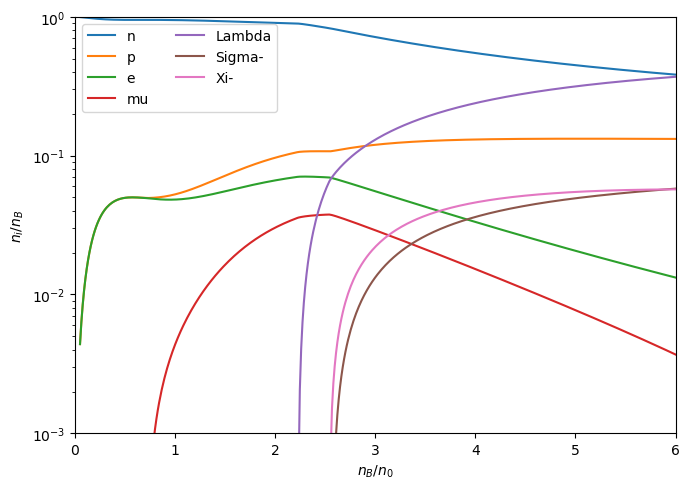

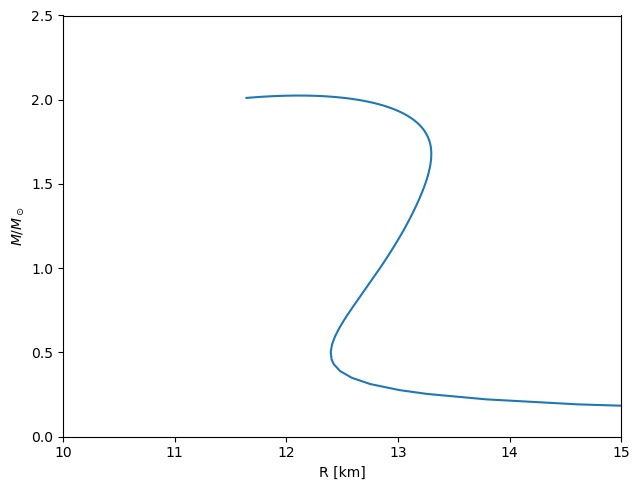

Calculated: Mmax=2.0250 Msun, Rmax=12.1148 km, nc/n0=5.7546, R1.5=13.2442 km, Yonset=2.2328 n0
Paper Table 2: Mmax=2.03 Msun, Rmax=12.0 km, nc/n0=5.8, R1.5=13.2 km, Yonset=2.2 n0
Numerics: max RMF residual=7.994e-13, max |charge residual|=3.485e-15 fm^-3


In [1]:
"""
Compact FSU2H B=0 EOS + TOV profiles.

Paper: Tolos, Centelles & Ramos, arXiv:1610.00919v2

Paper map:
Table 1       FSU2H parameters
Eq. (5)       effective masses
Eqs. (6)-(9)  meson fields
Eqs. (13)-(19) B=0 matter
Eq. (22)      beta equilibrium + charge neutrality
Eq. (23)      TOV
Eqs. (24)-(26) hyperon couplings

TOV output now retains radial profiles needed for L_nu^infinity.
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.interpolate import PchipInterpolator
from scipy.optimize import least_squares


# ============================================================
# Configuration
# ============================================================

BASE_DIR = (
    Path(__file__).resolve().parent
    if "__file__" in globals()
    else Path.cwd()
)

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

CRUST_FILE = "bcpm_sharma_crust_table_used.csv"

EOS_NPTS = 520
EOS_XMIN = 0.05
EOS_XMAX = 7.0
TOV_POINTS = 160


# ============================================================
# Constants
# ============================================================

PI = np.pi

HBARC = 197.3269804
HC3 = HBARC**3

MEVFM3_TO_CGS = 1.602176634e33

G_CGS = 6.67430e-8
C_CGS = 2.99792458e10
MSUN_G = 1.98847e33


# ============================================================
# FSU2H parameters — Table 1
# ============================================================

N0 = 0.1505

M_SIGMA = 497.479
M_OMEGA = 782.500
M_RHO   = 763.000
M_PHI   = 1020.0

G_SIGMA_N = np.sqrt(102.7200)
G_OMEGA_N = np.sqrt(169.5315)
G_RHO_N   = np.sqrt(247.3409)

KAPPA = 4.0014
LAMBDA = -0.013298
ZETA = 0.008
LAMBDA_W = 0.05

X_SIGMA = {
    "Lambda": 0.6113,
    "Sigma": 0.4665,
    "Xi": 0.3157,
}

X_OMEGA = {
    "Lambda": 2/3,
    "Sigma": 2/3,
    "Xi": 1/3,
}

X_RHO = {
    "Lambda": 0.0,
    "Sigma": 1.0,
    "Xi": 1.0,
}

X_PHI = {
    "Lambda": -0.8*np.sqrt(2)/3,
    "Sigma": -np.sqrt(2)/3,
    "Xi": -2*np.sqrt(2)/3,
}


# ============================================================
# Particles
#
# The RMF nucleon mass is 939 MeV, as in FSU2H Table 1.
# Physical weak-current masses belong in the FF/emissivity code.
# ============================================================

BARYONS = {
    "n":      dict(m=939.000,  q= 0, I3=-0.5, family="N"),
    "p":      dict(m=939.000,  q=+1, I3=+0.5, family="N"),

    "Lambda": dict(m=1115.683, q= 0, I3= 0.0, family="Lambda"),

    "Sigma+": dict(m=1189.370, q=+1, I3=+1.0, family="Sigma"),
    "Sigma0": dict(m=1192.642, q= 0, I3= 0.0, family="Sigma"),
    "Sigma-": dict(m=1197.449, q=-1, I3=-1.0, family="Sigma"),

    "Xi0":    dict(m=1314.860, q= 0, I3=+0.5, family="Xi"),
    "Xi-":    dict(m=1321.710, q=-1, I3=-0.5, family="Xi"),
}

LEPTONS = {
    "e":  dict(m=0.51099895, q=-1),
    "mu": dict(m=105.6583755, q=-1),
}

EXPORT_SPECIES = [*BARYONS, *LEPTONS]


for sp in BARYONS.values():

    fam = sp["family"]

    if fam == "N":

        sp.update(
            gs=G_SIGMA_N,
            gw=G_OMEGA_N,
            gr=G_RHO_N,
            gp=0.0,
        )

    else:

        sp.update(
            gs=X_SIGMA[fam] * G_SIGMA_N,
            gw=X_OMEGA[fam] * G_OMEGA_N,
            gr=X_RHO[fam] * G_RHO_N,
            gp=X_PHI[fam] * G_OMEGA_N,
        )


SIGMA_MAX = 0.999 * min(
    sp["m"] / sp["gs"]
    for sp in BARYONS.values()
)


# ============================================================
# B=0 Fermi gas
# Eqs. (13), (16), (18)
# ============================================================

def fermi_gas(EF, m):

    if EF <= m:
        return 0.0, 0.0, 0.0, 0.0

    kF = np.sqrt(EF**2 - m**2)

    log = np.log((kF + EF) / m )

    n = kF**3 / (3*PI**2)

    ns = ( m / (2*PI**2)* (EF*kF- m**2*log) )

    eps = ( kF*EF**3 + kF**3*EF - m**4*log ) / (8*PI**2)

    return n, ns, eps, kF


# ============================================================
# RMF matter
# ============================================================

def compute_state(x, nB_fm3):

    mu_n, mu_e, sigma, omega, rho, phi = x

    nB_target = nB_fm3 * HC3

    bdata = {}
    ldata = {}

    S = {
        key: 0.0
        for key in [
            "nb",
            "charge",
            "sig",
            "omg",
            "rh",
            "ph",
            "eps_f",
            "sum_mu_n",
        ]
    }


    # --------------------------------------------------------
    # Baryons
    # --------------------------------------------------------

    for name, sp in BARYONS.items():

        mstar = (
            sp["m"]
            - sp["gs"]*sigma
        )

        if mstar <= 0.0:
            raise ValueError(
                "Non-positive effective mass."
            )

        mu = (mu_n- sp["q"]*mu_e)

        U = (sp["gw"]*omega + sp["gr"]*sp["I3"]*rho + sp["gp"]*phi )

        EF = mu - U

        n, ns, eps, kF = fermi_gas(EF, mstar,)

        bdata[name] = {
            "n": n,
            "ns": ns,
            "eps": eps,
            "kF": kF,
            "mstar": mstar,
            "U": U,
            "mu": mu,
            "mustar": EF,
        }

        S["nb"]       += n
        S["charge"]   += sp["q"]*n
        S["sig"]      += sp["gs"]*ns
        S["omg"]      += sp["gw"]*n
        S["rh"]       += sp["gr"]*sp["I3"]*n
        S["ph"]       += sp["gp"]*n
        S["eps_f"]    += eps
        S["sum_mu_n"] += mu*n


    # --------------------------------------------------------
    # Leptons
    # --------------------------------------------------------

    for name, sp in LEPTONS.items():

        n, _, eps, kF = fermi_gas(mu_e,sp["m"],)

        ldata[name] = {
            "n": n,
            "eps": eps,
            "kF": kF,
            "mstar": sp["m"],
            "U": 0.0,
            "mu": mu_e,
            "mustar": mu_e,
        }

        S["charge"]   += sp["q"]*n
        S["eps_f"]    += eps
        S["sum_mu_n"] += mu_e*n


    # --------------------------------------------------------
    # Eq. (17)
    # --------------------------------------------------------

    eps_meson = (
        0.5*M_SIGMA**2*sigma**2
        + 0.5*M_OMEGA**2*omega**2
        + 0.5*M_RHO**2*rho**2
        + 0.5*M_PHI**2*phi**2
        + KAPPA/6*(G_SIGMA_N*sigma)**3
        + LAMBDA/24*(G_SIGMA_N*sigma)**4
        + ZETA/8*(G_OMEGA_N*omega)**4
        + 3*LAMBDA_W*(G_RHO_N* G_OMEGA_N* rho* omega)**2
    )

    eps = (S["eps_f"]+ eps_meson)

    pressure = (S["sum_mu_n"]- eps)


    # --------------------------------------------------------
    # Eqs. (6)-(9)
    # --------------------------------------------------------

    lhs = np.array([M_SIGMA**2*sigma+ KAPPA/2 * G_SIGMA_N**3*sigma**2 + LAMBDA/6 * G_SIGMA_N**4*sigma**3,

        M_OMEGA**2*omega + ZETA/6 * G_OMEGA_N**4*omega**3+ 2*LAMBDA_W * G_RHO_N**2* G_OMEGA_N**2* rho**2 * omega,

        M_RHO**2*rho + 2*LAMBDA_W * G_RHO_N**2 * G_OMEGA_N**2* omega**2 * rho,

        M_PHI**2*phi,
    ])

    rhs = np.array([ S["sig"], S["omg"], S["rh"], S["ph"],])

    S.update(nB_target=nB_target,eps_meson=eps_meson,eps=eps,pressure=pressure,lhs=lhs,rhs=rhs,)

    return bdata, ldata, S


def residuals(x, nB_fm3):

    try:
        _, _, S = compute_state(
            x,
            nB_fm3,
        )
    except Exception:
        return np.full(6, 1e6)

    nB = S["nB_target"]

    return np.r_[(S["nb"] - nB) / nB,S["charge"] / nB,(S["lhs"] - S["rhs"]) / nB,]


def solve_point(nB_fm3, previous=None):

    xn0 = nB_fm3 / N0

    guess = np.array(
        previous
        if previous is not None
        else [930 + 100*xn0,
            40 + 30*xn0,
            min(18 + 12*xn0, 0.9*SIGMA_MAX,),
            min(8 + 15*xn0, 120,),
            -3 - 2*min(xn0, 8),
            -max(xn0 - 2, 0),
        ]
    )

    lo = np.array([850,0,0,0,-250,-250,])

    hi = np.array([ 2500, 700, SIGMA_MAX, 220, 250, 250,])

    guess = np.clip(guess,lo,hi,)

    sol = least_squares(
        residuals,
        guess,
        args=(nB_fm3,),
        bounds=(lo, hi),
        xtol=1e-11,
        ftol=1e-11,
        gtol=1e-11,
        max_nfev=3000,
        x_scale="jac",
    )

    err = np.max(np.abs(sol.fun))

    if ( not sol.success or err > 1e-7 ):
        raise RuntimeError(
            f"RMF solve failed at "
            f"n/n0={xn0:.4f}, "
            f"residual={err:.3e}"
        )

    return sol.x, float(err)


# ============================================================
# EOS tables
# ============================================================

def eos_row(nB, x, err):

    b, l, S = compute_state( x, nB,)

    row = {
        "nB_fm3": nB,
        "nB_over_n0": nB/N0,

        "mu_n_MeV": x[0],
        "mu_e_MeV": x[1],

        "sigma_MeV": x[2],
        "omega_MeV": x[3],
        "rho_MeV": x[4],
        "phi_MeV": x[5],

        "eps_MeV_fm3": S["eps"]/HC3,
        "P_MeV_fm3": S["pressure"]/HC3,

        "solver_maxabs": err,
        "charge_residual_fm3":
            S["charge"]/HC3,
    }

    for name, d in {  **b,  **l, }.items():

        row.update({
            f"Y_{name}":
                d["n"]/S["nB_target"],

            f"n_{name}_fm3":
                d["n"]/HC3,

            f"kF_{name}_MeV":
                d["kF"],

            f"Mstar_{name}_MeV":
                d["mstar"],

            f"U_{name}_MeV":
                d["U"],

            f"mu_{name}_MeV":
                d["mu"],

            f"mustar_{name}_MeV":
                d["mustar"],
        })

    return row


def build_eos_table(npts=EOS_NPTS,xmin=EOS_XMIN,xmax=EOS_XMAX,):

    rows = []
    previous = None

    for i, xn0 in enumerate(np.linspace(xmin,xmax,npts,)):

        previous, err = solve_point(xn0*N0,previous,)

        rows.append(eos_row(xn0*N0,previous,err,) )

        if ( i == 0 or (i+1) % max(1, npts//20) == 0):
            print(
                f"EOS {i+1:4d}/{npts}: "
                f"n/n0={xn0:6.3f}"
            )

    return pd.DataFrame(rows)


def build_du_table(eos):

    quantities = [ ("Y", ""), ("n", "_fm3"), ("kF", "_MeV"), ("Mstar", "_MeV"), ("U", "_MeV"), ("mu", "_MeV"), ("mustar", "_MeV"),]

    cols = [ "nB_fm3", "nB_over_n0", "eps_MeV_fm3", "P_MeV_fm3", ]

    cols += [ f"{q}_{sp}{suffix}" for sp in EXPORT_SPECIES for q, suffix in quantities]

    out = eos.reindex(columns=cols).copy()

    out["T_MeV"] = 0.0

    return out


# ============================================================
# Crust
# ============================================================

def load_crust(path=CRUST_FILE):

    crust = pd.read_csv(path)

    crust["eps_MeV_fm3"] = ( crust["rho_g_cm3"] * C_CGS**2 / MEVFM3_TO_CGS )

    crust["P_MeV_fm3"] = ( crust["P_erg_cm3"] / MEVFM3_TO_CGS )

    crust["nB_over_n0"] = ( crust["nB_fm3"]  / N0 )

    return ( crust.sort_values("P_MeV_fm3").drop_duplicates("P_MeV_fm3").reset_index(drop=True))


def combine_eos(core, crust):

    Pmatch = crust[ "P_MeV_fm3"].max()

    c = crust[[ "region", "nB_fm3", "nB_over_n0",  "eps_MeV_fm3", "P_MeV_fm3", ] ].copy()

    c["source"] = ("BCPM/Sharma crust" )

    k = core.loc[core["P_MeV_fm3"] > Pmatch,[ "nB_fm3", "nB_over_n0", "eps_MeV_fm3", "P_MeV_fm3",],].copy()

    k["region"] = "FSU2H_core"
    k["source"] = "FSU2H hyperonic core"

    return (pd.concat( [c, k], ignore_index=True,).sort_values("P_MeV_fm3").reset_index(drop=True) )


# ============================================================
# TOV interpolation
# ============================================================

def make_tov_interpolators(eos):

    d = eos[ (eos.P_MeV_fm3 > 0)  & (eos.eps_MeV_fm3 > 0)].sort_values( "P_MeV_fm3" )

    P = ( d.P_MeV_fm3.to_numpy() * MEVFM3_TO_CGS )

    E = ( d.eps_MeV_fm3.to_numpy()* MEVFM3_TO_CGS)

    X = d.nB_over_n0.to_numpy()

    keep = np.r_[  True, np.diff(P) > 0 ]

    P, E, X = ( P[keep], E[keep],  X[keep],)

    logP = np.log(P)

    e_interp = PchipInterpolator( logP, np.log(E), extrapolate=False,)

    x_interp = PchipInterpolator( logP, X, extrapolate=False, )

    Pmin, Pmax = P[0], P[-1]

    def eps_of_P(p):
        p = np.asarray(p, float)
        out = np.exp(e_interp(np.log(np.clip( p, Pmin, Pmax,))))
        return ( float(out) if out.ndim == 0  else out  )

    def nb_of_P(p):
        p = np.asarray(p, float)
        out = x_interp(np.log( np.clip(p,Pmin,Pmax, ))  )
        return (float(out) if out.ndim == 0 else out )

    return (eps_of_P, nb_of_P,Pmin, Pmax,  )


# ============================================================
# TOV + radial profile
#
# Solves:
#   m(r), P(r), Phi(r)
#
# Phi is normalized afterwards through
#
#   exp[2 Phi(R)] = 1 - 2GM/(Rc^2).
# ============================================================

def integrate_tov(Pc,eps_of_P, nb_of_P,P_surface,):

    r0 = 1.0

    rho_c = (eps_of_P(Pc) / C_CGS**2)

    m0 = (4*PI*r0**3* rho_c/ 3 )

    y0 = [ m0, Pc, 0.0, ]


    def rhs(r, y):

        m, P, Phi = y

        if P <= P_surface:
            return [0.0, 0.0, 0.0]

        eps = eps_of_P(P)
        rho = eps/C_CGS**2

        A = ( 1.0 - 2*G_CGS*m / (r*C_CGS**2) )

        grav = (  m + 4*PI*r**3*P / C_CGS**2)

        dm = ( 4*PI*r**2*rho )

        dP = ( -G_CGS  * ( rho + P/C_CGS**2)* grav  / (r**2*A) )

        dPhi = ( G_CGS * grav / ( C_CGS**2  * r**2* A) )

        return [dm, dP, dPhi,]


    def surface(_, y):
        return y[1] - P_surface


    surface.terminal = True
    surface.direction = -1


    sol = solve_ivp( rhs,(r0, 5e6), y0, events=surface,max_step=1e4, rtol=2e-6, atol=[1e14,  1e8,1e-10, ],)


    if not len(sol.t_events[0]):
        raise RuntimeError( "TOV did not reach the surface.")


    # Terminal surface solution
    ys = sol.y_events[0][0]
    rs = sol.t_events[0][0]

    # solve_ivp normally includes the terminal point,
    # but enforce it explicitly.
    r = sol.t.copy()
    y = sol.y.copy()

    if not np.isclose( r[-1], rs,rtol=0, atol=1e-6, ):
        r = np.r_[r, rs]
        y = np.column_stack([y, ys])


    m, P, Phi = y

    M = m[-1]
    R = r[-1]


    # --------------------------------------------------------
    # Correct normalization of Phi
    # --------------------------------------------------------

    Phi_surface = ( 0.5* np.log( 1.0 - 2*G_CGS*M / (R*C_CGS**2)) )

    Phi += ( Phi_surface - Phi[-1]  )


    # --------------------------------------------------------
    # Reconstruct local EOS quantities
    # --------------------------------------------------------

    eps = eps_of_P(P)
    nb = nb_of_P(P)

    compactness = ( 2*G_CGS*m / (r*C_CGS**2))


    profile = pd.DataFrame({

        "r_km":r/1e5,

        "m_Msun":m/MSUN_G,

        "P_MeV_fm3":P/MEVFM3_TO_CGS,

        "eps_MeV_fm3":   eps/MEVFM3_TO_CGS,

        "nB_over_n0":  nb,

        "Phi":    Phi,

        "expPhi": np.exp(Phi),

        "compactness": compactness,
    })


    return ( M/MSUN_G, R/1e5, profile,  )


# ============================================================
# TOV sequence + profiles
# ============================================================

def build_tov_sequence( core, combined, npoints=TOV_POINTS,):

    ( eps_of_P, nb_of_P, Pmin, Pmax, ) = make_tov_interpolators(combined)

    # Numerical surface = lowest crust pressure.
    P_surface = Pmin

    Pmatch = combined.loc[  combined.region != "FSU2H_core", "P_MeV_fm3",].max()

    central = ( core[ (core.P_MeV_fm3 > 1.01*Pmatch) & (core.nB_over_n0 >= 1.0)].sort_values("nB_fm3") )

    indices = np.unique( np.linspace(  0,len(central)-1,npoints,).astype(int)  )

    central = central.iloc[ indices ]

    rows = []
    profiles = []


    for _, state in central.iterrows():

        Pc = ( state.P_MeV_fm3 * MEVFM3_TO_CGS)

        if Pc >= Pmax:
            continue

        M, R, profile = integrate_tov(  Pc, eps_of_P,  nb_of_P, P_surface,)

        model = len(rows)

        profile["model"] = model
        profile["M_star_Msun"] = M
        profile["R_star_km"] = R
        profile["nB_c_over_n0"] = (
            state.nB_over_n0
        )

        profiles.append(profile)

        rows.append({
            "model": model,
            "nB_c_fm3":state.nB_fm3,
            "nB_c_over_n0":  state.nB_over_n0,
            "eps_c_MeV_fm3":state.eps_MeV_fm3,
            "P_c_MeV_fm3": state.P_MeV_fm3,
            "M_Msun": M,
            "R_km": R,
        })


    return ( pd.DataFrame(rows),profiles,)


# ============================================================
# Validation
# ============================================================

def paper_checks(core, tov):

    i = tov["M_Msun"].to_numpy().argmax()

    mx = tov.iloc[i]

    stable = (
        tov.iloc[:i+1]
        .sort_values("M_Msun")
    )

    R15 = np.interp( 1.5,stable.M_Msun,stable.R_km,)

    hyperons = [
        "Lambda",
        "Sigma+",
        "Sigma0",
        "Sigma-",
        "Xi0",
        "Xi-",
    ]

    Yh = core[
        [f"Y_{s}" for s in hyperons]
    ].sum(axis=1)

    onset = core.loc[
        Yh > 1e-8,
        "nB_over_n0",
    ].min()

    return (
        f"Calculated: "
        f"Mmax={mx.M_Msun:.4f} Msun, "
        f"Rmax={mx.R_km:.4f} km, "
        f"nc/n0={mx.nB_c_over_n0:.4f}, "
        f"R1.5={R15:.4f} km, "
        f"Yonset={onset:.4f} n0\n"

        "Paper Table 2: "
        "Mmax=2.03 Msun, "
        "Rmax=12.0 km, "
        "nc/n0=5.8, "
        "R1.5=13.2 km, "
        "Yonset=2.2 n0\n"

        f"Numerics: "
        f"max RMF residual="
        f"{core.solver_maxabs.max():.3e}, "
        f"max |charge residual|="
        f"{core.charge_residual_fm3.abs().max():.3e} fm^-3"
    )


# ============================================================
# Simple check plots
# ============================================================

def make_plots(core, combined, tov):

    # Composition
    fig, ax = plt.subplots(figsize=(7, 5))

    for s in [
        "n",
        "p",
        "e",
        "mu",
        "Lambda",
        "Sigma-",
        "Xi-",
    ]:

        y = core[f"Y_{s}"].where(
            core[f"Y_{s}"] > 1e-5
        )

        ax.plot(
            core.nB_over_n0,
            y,
            label=s,
        )

    ax.set(
        xlabel=r"$n_B/n_0$",
        ylabel=r"$n_i/n_B$",
        yscale="log",
        xlim=(0, 6),
        ylim=(1e-3, 1),
    )

    ax.legend(ncol=2)
    fig.tight_layout()

    fig.savefig(OUTPUT_DIR / "fsu2h_particle_fractions.png", dpi=220,)
    plt.show()
    plt.close(fig)


    # M-R
    fig, ax = plt.subplots(figsize=(6.5, 5))

    ax.plot( tov.R_km, tov.M_Msun,)

    ax.set(
        xlabel="R [km]",
        ylabel=r"$M/M_\odot$",
    )
    ax.set_ylim(0,2.5)
    ax.set_xlim(10,15)
    fig.tight_layout()

    fig.savefig(
        OUTPUT_DIR /
        "fsu2h_mass_radius.png",
        dpi=220,
    )
    plt.show()
    plt.close(fig)


# ============================================================
# Main
# ============================================================

def main():

    print("Building FSU2H EOS...")
    core = build_eos_table()

    print("Loading crust...")
    crust = load_crust()

    combined = combine_eos( core, crust,)

    du = build_du_table( core )

    print("Solving TOV sequence...")
    tov, profiles = build_tov_sequence( core,combined,)


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    core.to_csv( OUTPUT_DIR /"fsu2h_core_eos.csv",index=False, )

    du.to_csv( OUTPUT_DIR / "fsu2h_direct_urca_inputs.csv", index=False,)

    combined.to_csv(OUTPUT_DIR / "fsu2h_combined_eos.csv", index=False,)

    tov.to_csv(OUTPUT_DIR / "fsu2h_tov_sequence.csv", index=False,)

    # Convenient single file containing all radial profiles.
    pd.concat( profiles,ignore_index=True, ).to_pickle(OUTPUT_DIR /   "fsu2h_tov_profiles.pkl" )

    make_plots( core,combined,tov, )

    summary = paper_checks( core,tov,)

    print(summary)

    ( OUTPUT_DIR / "fsu2h_summary.txt").write_text(summary + "\n")


    return ( core, du, crust, combined, tov, profiles, )


# ============================================================
# Run
# ============================================================

( core_df, du_df, crust_df, combined_df, tov_df, tov_profiles,) = main()


# Direct-Urca input table
df = du_df

The orginal data in F1_F2_Isovector.pkl are not mine to share. So this kernel will not work. You can use the next one where I use the fits from the orignal paper. Another note is that the Lambda to proton form factors are re-fitted. This happened because in the published paper we fit the Helicity form factors and from there obtain the Weinberg ones. The only issue is that at q^2=q^2_max you end up having and indetermine expression that python doesn't know how to handle. This could lead to a fake singular point, and since we extrapolate beyond q^2_max a re-fit was necessary

In [2]:
"""Standalone form-factor definitions and diagnostic plots.

Requires only:
  F1_F2_Proton.pkl
  F1_F2_Isovector.pkl

All outputs use Eq. (37):
  Gamma^mu = gamma^mu(f1-g1 gamma5)
           + i sigma^{mu nu}q_nu/(M1+M2)(f2-g2 gamma5)
           + q^mu/M1(f3-g3 gamma5).
"""

import os
import pickle
import sys
from dataclasses import dataclass
from pathlib import Path

try:
    import gvar as gv
except ImportError as exc:
    raise ImportError("Install gvar first: pip install gvar") from exc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# 1. User settings
# ============================================================
F12_PROTON_PICKLE_CANDIDATES = [
    "F1_F2_Proton.pkl",
    "../../PhD/Neutrino/F1_F2_Proton.pkl",
    "../F1_F2_Proton.pkl",
]

F12_ISOVECTOR_PICKLE_CANDIDATES = [
    "F1_F2_Isovector.pkl",
    "../../PhD/Neutrino/F1_F2_Isovector.pkl",
    "../F1_F2_Isovector.pkl",
]


def first_existing_path(candidates, required=True):
    for p in candidates:
        if os.path.exists(p):
            return p
    if required:
        raise FileNotFoundError(
            "Could not find any of these files:\n" + "\n".join(candidates)
        )
    return None


F12_PROTON_PICKLE = first_existing_path(F12_PROTON_PICKLE_CANDIDATES, required=False)
F12_ISOVECTOR_PICKLE = first_existing_path(F12_ISOVECTOR_PICKLE_CANDIDATES, required=False)


OUTPUT_DIR = Path("form_factor_plots")
Q2_MIN_GEV2 = -0.20                 # spacelike left edge
Q2_MAX_GEV2 = 0.0                   # use 0.0 to inspect the LQCD-fit region
# Set Q2_MAX_GEV2 = None to extend each plot to (M1-M2)^2.
N_PLOT = 300
SU3_PLOT_SOURCE = "SU3"             # use "SU3_STATIC" for flat charges
SHOW_ERRORS = True
SAVE_PLOTS = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. Constants and channel definitions
# ============================================================

M_PI_GEV = 0.135
M_K_GEV = 0.493677
M_N_REF_GEV = 0.938918
M_N_REF_MEV = 1000.0 * M_N_REF_GEV

MASS = {
    "n": 939.5654133, "p": 938.2720813, "Lambda": 1115.683,
    "Sigma-": 1197.449, "Sigma+": 1189.370,
    "Xi-": 1321.710, "Xi0": 1314.860,
}

FF_CHANNELS = {
    "n_to_p":               ("n", "p", r"$n\to p$"),
    "Lambda_to_p":          ("Lambda", "p", r"$\Lambda\to p$"),
    "Sigma_minus_to_n":     ("Sigma-", "n", r"$\Sigma^-\to n$"),
    "Xi_minus_to_Lambda":   ("Xi-", "Lambda", r"$\Xi^-\to\Lambda$"),
    "Xi_minus_to_Xi0":      ("Xi-", "Xi0", r"$\Xi^-\to\Xi^0$"),
    "Xi0_to_Sigma_plus":    ("Xi0", "Sigma+", r"$\Xi^0\to\Sigma^+$"),
}

# Eqs. (66)-(67): X_channel = a F + b D.
SU3_AB = {
    "n_to_p": (1.0, 1.0),
    "Lambda_to_p": (-np.sqrt(3 / 2), -np.sqrt(1 / 6)),
    "Sigma_minus_to_n": (-1.0, 1.0),
    "Xi_minus_to_Lambda": (np.sqrt(3 / 2), -np.sqrt(1 / 6)),
    "Xi_minus_to_Xi0": (1.0, -1.0),
    "Xi0_to_Sigma_plus": (1.0, 1.0),
}

F_PLUS_D, F_MINUS_D = 1.2670, -0.341
F_AX = 0.5 * (F_PLUS_D + F_MINUS_D)
D_AX = 0.5 * (F_PLUS_D - F_MINUS_D)
X_AX = F_AX / (F_AX + D_AX)

# Known channel-specific f1(0) values; hybrid shape remains nucleon LQCD.
F1_ANCHOR = {
    "Sigma_minus_to_n": gv.gvar(-0.9571, 0.0060),
    "Xi0_to_Sigma_plus": gv.gvar(0.9755, 0.0039),
}

FF_NAMES = ("f1", "f2", "f3", "g1", "g2", "g3")
FF_TITLES = {x: rf"${x[0]}_{x[1]}(q^2)$" for x in FF_NAMES}


@dataclass(frozen=True)
class FormFactors:
    f1: object
    f2: object
    f3: object
    g1: object
    g2: object
    g3: object

# ============================================================
# 3. Small helpers
# ============================================================

def find_file(candidates, description):
    for path in candidates:
        if os.path.exists(path):
            print(f"{description}: {path}")
            return path
    raise FileNotFoundError(
        f"Could not find {description}. Tried:\n" + "\n".join(candidates)
    )


def make_psd(cov, floor=1e-14):
    cov = 0.5 * (np.asarray(cov, float) + np.asarray(cov, float).T)
    w, v = np.linalg.eigh(cov)
    return v @ np.diag(np.clip(w, floor, None)) @ v.T


def gvar_vector(mean, error, corr):
    error = np.asarray(error, float)
    return gv.gvar(np.asarray(mean, float), make_psd(np.outer(error, error) * corr))


def Q2_from_q2(q2_MeV2):
    return -float(q2_MeV2) * 1e-6


def zmap(Q2, tcut, t0=0.0):
    a, b = np.sqrt(tcut + Q2), np.sqrt(tcut + t0)
    return (a - b) / (a + b)


def masses(channel):
    b1, b2, _ = FF_CHANNELS[channel]
    return MASS[b1], MASS[b2]


def vector_coefficients(channel):
    a, b = SU3_AB[channel]
    return 1.5 * (a - b), -0.5 * a + 1.5 * b


def axial_coefficient(channel):
    a, b = SU3_AB[channel]
    return a * X_AX + b * (1.0 - X_AX)
# ============================================================
# PCAC induced-pseudoscalar form factor in Eq. (37)
# ============================================================

CHANNEL_DELTA_S = {
    "n_to_p": 0,
    "Lambda_to_p": 1,
    "Sigma_minus_to_n": 1,
    "Xi_minus_to_Lambda": 1,
    "Xi_minus_to_Xi0": 0,
    "Xi0_to_Sigma_plus": 1,
}


def pcac_g3(channel, q2_MeV2, g1):
    """
    Induced-pseudoscalar form factor in the convention

        q^mu / M1 * g3(q^2)

    used in Eq. (37).

    g3(q^2) =
        M1 (M1 + M2) g1(q^2) / (mP^2 - q^2)

    P = pion for Delta S = 0
    P = kaon for |Delta S| = 1
    """
    M1_MeV, M2_MeV = masses(channel)

    M1_GeV = M1_MeV * 1.0e-3
    M2_GeV = M2_MeV * 1.0e-3
    q2_GeV2 = q2_MeV2 * 1.0e-6

    if CHANNEL_DELTA_S[channel] == 0:
        pole_mass_GeV = M_PI_GEV
    else:
        pole_mass_GeV = M_K_GEV

    return (
        M1_GeV
        * (M1_GeV + M2_GeV)
        / (pole_mass_GeV**2 - q2_GeV2)
        * g1
    )
# ============================================================
# 4. Load proton/isovector F1,F2 continuum fits
# ============================================================

# Compatibility with functions stored inside the old pickles.
def r2(a, r):
    return r[0] + a**2 * r[1]


def form_fact(X, r):
    Q2, a = X[:, 0], X[:, 1]
    return np.r_[
        1 / (1 + Q2 * r2(a, r[:2]) / 12) ** 2,
        r2(a, r[2:4]) / (1 + Q2 * r2(a, r[4:6]) / 12) ** 2,
    ]


sys.modules["__main__"].r2 = r2
sys.modules["__main__"].form_fact = form_fact


class CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "__main__" and name == "r2":
            return r2
        if module == "__main__" and name == "form_fact":
            return form_fact
        return super().find_class(module, name)


class VectorFit:
    def __init__(self, path):
        with open(path, "rb") as f:
            data = CompatUnpickler(f).load()
        if "fit_mean" not in data or "fit_cov" not in data:
            raise KeyError(f"{path} must contain fit_mean and fit_cov")
        self.func = data.get("func", form_fact)
        self.pars = gv.gvar(data["fit_mean"], make_psd(data["fit_cov"]))

    def __call__(self, q2_MeV2):
        X = np.array([[Q2_from_q2(q2_MeV2), 0.0]])  # continuum a=0
        y = self.func(X, self.pars)
        return y[0], y[1]

# ============================================================
# 5. Nucleon axial LQCD: GA and GP
# ============================================================

class NucleonAxial:
    def __init__(self):
        self.ga = gvar_vector(
            [1.245, -1.19, -0.54, -0.10],
            [0.031, 0.18, 0.61, 1.30],
            np.array([
                [1.000, -0.421, 0.247, -0.246],
                [-0.421, 1.000, -0.918, 0.799],
                [0.247, -0.918, 1.000, -0.952],
                [-0.246, 0.799, -0.952, 1.000],
            ]),
        )
        self.hp = gvar_vector(
            [4.62, -3.0, -4.7, -0.10],
            [0.33, 1.20, 2.80, 3.70],
            np.array([
                [1.000, -0.812, 0.414, 0.151],
                [-0.812, 1.000, -0.819, 0.230],
                [0.414, -0.819, 1.000, -0.713],
                [0.151, 0.230, -0.713, 1.000],
            ]),
        )
        self.tcut = (3 * M_PI_GEV) ** 2

    def poly(self, Q2, coeffs, t0):
        z = zmap(Q2, self.tcut, t0)
        return sum(c * z**i for i, c in enumerate(coeffs))

    def __call__(self, q2_MeV2):
        Q2 = Q2_from_q2(q2_MeV2)
        GA = self.poly(Q2, self.ga, 0.0)
        HP = self.poly(Q2, self.hp, -M_PI_GEV**2)
        return GA, HP / (Q2 + M_PI_GEV**2)

# ============================================================
# 6. Direct Lambda -> p LQCD, all six form factors
# ============================================================

class LambdaProtonLQCD:
    def __init__(self):
        vm = [1.1901, -0.345, 1.442, -1.38, 0.0293, 0.097]
        ve = [0.0060, 0.049, 0.015, 0.11, 0.0084, 0.059]
        vc = np.array([
            [1.00, -0.73, 0.15, -0.11, -0.49, 0.17],
            [-0.73, 1.00, -0.13, 0.26, 0.44, -0.14],
            [0.15, -0.13, 1.00, -0.76, -0.11, 0.11],
            [-0.11, 0.26, -0.76, 1.00, 0.06, -0.06],
            [-0.49, 0.44, -0.11, 0.06, 1.00, -0.80],
            [0.17, -0.14, 0.11, -0.06, -0.80, 1.00],
        ])
        am = [0.8063, -0.189, 0.123, -0.85, 5.232, -2.34]
        ae = [0.0044, 0.038, 0.018, 0.12, 0.060, 0.45]
        ac = np.array([
            [1.00, -0.71, -0.38, 0.24, 0.37, -0.29],
            [-0.71, 1.00, 0.31, -0.21, -0.32, 0.45],
            [-0.38, 0.31, 1.00, -0.80, -0.18, 0.14],
            [0.24, -0.21, -0.80, 1.00, 0.19, -0.19],
            [0.37, -0.32, -0.18, 0.19, 1.00, -0.84],
            [-0.29, 0.45, 0.14, -0.19, -0.84, 1.00],
        ])
        xc = np.array([
            [0.62, -0.41, -0.51, 0.30, 0.24, -0.19],
            [-0.50, 0.66, 0.40, -0.25, -0.29, 0.33],
            [0.41, -0.27, -0.12, 0.07, 0.39, -0.30],
            [-0.30, 0.46, 0.07, 0.00, -0.32, 0.39],
            [-0.30, 0.25, 0.39, -0.33, -0.24, 0.22],
            [0.10, -0.08, -0.27, 0.32, 0.28, -0.26],
        ])

        mean, err = np.array(vm + am), np.array(ve + ae)
        corr = np.eye(12)
        corr[:6, :6], corr[6:, 6:] = vc, ac
        corr[:6, 6:], corr[6:, :6] = xc, xc.T
        self.p = gv.gvar(mean, make_psd(np.outer(err, err) * corr))
        self.poles = [0.892, 0.892, 0.680, 1.254, 1.254, 0.493677]
        self.tcut = (M_PI_GEV + 0.495) ** 2

    def component(self, q2, a0, a1, pole):
        Q2 = Q2_from_q2(q2)
        z = zmap(Q2, self.tcut)
        return (a0 + a1 * z - (a0 + a1) * z**2) / (1 + Q2 / pole**2)

    def __call__(self, q2):
        F1, F2, F3, G1, G2, G3 = [
            self.component(
                q2,
                self.p[2 * i],
                self.p[2 * i + 1],
                self.poles[i],
            )
            for i in range(6)
        ]
        def convert_lambda_p_to_eq37(
            F1, F2, F3,
            G1, G2, G3,
            phase=1.0,
        ):
            """
            Convert native Lambda->p lattice form factors to Eq. (37).

            phase may be +1 or -1, but it must multiply all six
            form factors consistently.
            """
            M_LAMBDA = MASS["Lambda"]
            M_PROTON = MASS["p"]

            tensor_ratio = (
                (M_LAMBDA + M_PROTON)
                / M_LAMBDA
            )

            return FormFactors(
                f1=phase * F1,
                f2=phase * (tensor_ratio * F2),
                f3=phase * F3,
                g1=phase * G1,
                g2=phase * (tensor_ratio * G2),
                g3=phase * G3,
            )
        return convert_lambda_p_to_eq37(
            F1, F2, F3,
            G1, G2, G3,
            phase=-1.0,  # only if matching your negative SU(3) phase
        )
# ============================================================
# 7. Older SU(3) dipole basis
# ============================================================

class SU3DipoleBasis:
    def __call__(self, q2_MeV2):
        q2 = q2_MeV2 * 1e-6
        kp, kn, lam, MV, MA = 1.792847, -1.913043, 5.6, 0.84, 1.03
        tau = q2 / (4 * M_N_REF_GEV**2)
        GEp = 1 / (1 - q2 / MV**2) ** 2
        GMp, GMn = (1 + kp) * GEp, kn * GEp
        GEn = tau * kn * GEp / (1 - lam * q2 / (4 * M_N_REF_GEV**2))
        fp1, fp2 = (GEp - tau*GMp)/(1-tau), (GMp-GEp)/(1-tau)
        fn1, fn2 = (GEn - tau*GMn)/(1-tau), (GMn-GEn)/(1-tau)
        GA = F_PLUS_D / (1 - q2 / MA**2) ** 2
        GP = 4 * M_N_REF_GEV**2 * GA / (M_PI_GEV**2 - q2)
        return dict(fp1=fp1, fp2=fp2, fiso1=fp1-fn1,
                    fiso2=fp2-fn2, GA=GA, GP=GP)

# ============================================================
# 8. One form-factor library and one public interface
# ============================================================

class FormFactorLibrary:
    def __init__(self, proton_pickle, isovector_pickle):
        self.proton = VectorFit(proton_pickle)
        self.isovector = VectorFit(isovector_pickle)
        self.axial = NucleonAxial()
        self.lambda_p = LambdaProtonLQCD()
        self.su3_basis = SU3DipoleBasis()

    def lqcd_basis(self, q2):
        fp1, fp2 = self.proton(q2)
        fi1, fi2 = self.isovector(q2)
        GA, GP = self.axial(q2)
        return dict(fp1=fp1, fp2=fp2, fiso1=fi1,
                    fiso2=fi2, GA=GA, GP=GP)

    def from_basis(self, channel, basis, q2_MeV2):
        cp, ciso = vector_coefficients(channel)
        cA = axial_coefficient(channel)

        M1, M2 = masses(channel)

        # SU(3) vector construction.
        f1 = (
            cp * basis["fp1"]
            + ciso * basis["fiso1"]
        )

        f2 = (
            cp * basis["fp2"]
            + ciso * basis["fiso2"]
        )

        # SU(3) axial coefficient times the nucleon axial shape.
        g1 = cA * basis["GA"]

        # PCAC relation with the correct pion or kaon pole.
        g3 = pcac_g3(
            channel=channel,
            q2_MeV2=q2_MeV2,
            g1=g1,
        )

        return FormFactors(
            f1=f1,
            f2=f2,
            f3=0.0,
            g1=g1,
            g2=0.0,
            g3=g3,
        )

    def nucleon_direct(self, q2):
        b = self.lqcd_basis(q2)
        M1, M2 = masses("n_to_p")
        return FormFactors(
            b["fiso1"],
            (M1+M2)/(2*M_N_REF_MEV) * b["fiso2"],
            0.0, b["GA"], 0.0,
            M1/(2*M_N_REF_MEV) * b["GP"],
        )
    def hybrid(self, channel, q2_MeV2):
        basis = self.lqcd_basis(q2_MeV2)

        ff = self.from_basis(
            channel=channel,
            basis=basis,
            q2_MeV2=q2_MeV2,
        )

        # Optional channel-specific f1(0) anchor.
        if channel not in F1_ANCHOR:
            return ff

        ff_at_zero = self.from_basis(
            channel=channel,
            basis=self.lqcd_basis(0.0),
            q2_MeV2=0.0,
        )

        anchored_f1 = (
            F1_ANCHOR[channel]
            * ff.f1
            / ff_at_zero.f1
        )

        return FormFactors(
            f1=anchored_f1,
            f2=ff.f2,
            f3=ff.f3,
            g1=ff.g1,
            g2=ff.g2,
            g3=ff.g3,
        )

    def su3(self, channel, q2, static=False):
        q2_used = 0.0 if static else q2

        return self.from_basis(channel=channel,basis=self.su3_basis(q2_used),q2_MeV2=q2_used,)

    def get(self, channel, q2, source="AUTO"):
        if channel not in FF_CHANNELS:
            raise ValueError(f"Unknown channel: {channel}")
        source = source.upper()
        if source == "SU3":
            return self.su3(channel, q2)
        if source == "SU3_STATIC":
            return self.su3(channel, q2, static=True)
        if source in ("LQCD", "LQCD_DIRECT"):
            if channel == "n_to_p":
                return self.nucleon_direct(q2)
            if channel == "Lambda_to_p":
                return self.lambda_p(q2)
            raise ValueError(f"No direct LQCD input for {channel}")
        if source == "HYBRID":
            return self.hybrid(channel, q2)
        if source == "AUTO":
            if channel == "n_to_p":
                return self.nucleon_direct(q2)
            if channel == "Lambda_to_p":
                return self.lambda_p(q2)
            return self.hybrid(channel, q2)
        raise ValueError("source: SU3, SU3_STATIC, LQCD_DIRECT, HYBRID, or AUTO")



# ============================================================
# Initialise the form-factor library
# ============================================================

PROTON_PICKLE = find_file(F12_PROTON_PICKLE_CANDIDATES, "proton F1/F2 pickle")
ISOVECTOR_PICKLE = find_file(F12_ISOVECTOR_PICKLE_CANDIDATES, "isovector F1/F2 pickle")

FF_LIBRARY = FormFactorLibrary(
    proton_pickle=PROTON_PICKLE,
    isovector_pickle=ISOVECTOR_PICKLE,
)

def get_form_factors(channel, q2_MeV2, source="AUTO"):
    return FF_LIBRARY.get(channel, q2_MeV2, source)


proton F1/F2 pickle: ../../PhD/Neutrino/F1_F2_Proton.pkl
isovector F1/F2 pickle: ../../PhD/Neutrino/F1_F2_Isovector.pkl


In [3]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gvar as gv


# ============================================================
# Settings
# ============================================================

OUTPUT_DIR = Path("form_factor_plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Q2_MIN_GEV2 = -0.20
Q2_MAX_GEV2 = 0.0
N_PLOT = 300

SU3_PLOT_SOURCE = "SU3"
SHOW_ERRORS = True
SAVE_PLOTS = True


# ============================================================
# Constants
# ============================================================

M_PI_GEV = 0.135
M_K_GEV = 0.493677

M_N_REF_GEV = 0.9389
M_N_REF_MEV = 1000.0 * M_N_REF_GEV

T_CUT_VECTOR = (2.0 * M_PI_GEV) ** 2

MASS = {
    "n": 939.5654133,
    "p": 938.2720813,
    "Lambda": 1115.683,
    "Sigma-": 1197.449,
    "Sigma+": 1189.370,
    "Xi-": 1321.710,
    "Xi0": 1314.860,
}

FF_CHANNELS = {
    "n_to_p": ("n", "p", r"$n\to p$"),
    "Lambda_to_p": ("Lambda", "p", r"$\Lambda\to p$"),
    "Sigma_minus_to_n": ("Sigma-", "n", r"$\Sigma^-\to n$"),
    "Xi_minus_to_Lambda": ("Xi-", "Lambda", r"$\Xi^-\to\Lambda$"),
    "Xi_minus_to_Xi0": ("Xi-", "Xi0", r"$\Xi^-\to\Xi^0$"),
    "Xi0_to_Sigma_plus": ("Xi0", "Sigma+", r"$\Xi^0\to\Sigma^+$"),
}

SU3_AB = {
    "n_to_p": (1.0, 1.0),
    "Lambda_to_p": (-np.sqrt(3 / 2), -np.sqrt(1 / 6)),
    "Sigma_minus_to_n": (-1.0, 1.0),
    "Xi_minus_to_Lambda": (np.sqrt(3 / 2), -np.sqrt(1 / 6)),
    "Xi_minus_to_Xi0": (1.0, -1.0),
    "Xi0_to_Sigma_plus": (1.0, 1.0),
}

F_PLUS_D = 1.2670
F_MINUS_D = -0.341

F_AX = 0.5 * (F_PLUS_D + F_MINUS_D)
D_AX = 0.5 * (F_PLUS_D - F_MINUS_D)

X_AX = F_AX / (F_AX + D_AX)

F1_ANCHOR = {
    "Sigma_minus_to_n": gv.gvar(-0.9571, 0.0060),
    "Xi0_to_Sigma_plus": gv.gvar(0.9755, 0.0039),
}

CHANNEL_DELTA_S = {
    "n_to_p": 0,
    "Lambda_to_p": 1,
    "Sigma_minus_to_n": 1,
    "Xi_minus_to_Lambda": 1,
    "Xi_minus_to_Xi0": 0,
    "Xi0_to_Sigma_plus": 1,
}

FF_NAMES = ("f1", "f2", "f3", "g1", "g2", "g3")

FF_TITLES = {
    x: rf"${x[0]}_{x[1]}(q^2)$"
    for x in FF_NAMES
}


@dataclass(frozen=True)
class FormFactors:
    f1: object
    f2: object
    f3: object
    g1: object
    g2: object
    g3: object


# ============================================================
# Helpers
# ============================================================

def make_psd(cov, floor=1e-14):
    cov = np.asarray(cov, float)
    cov = 0.5 * (cov + cov.T)

    w, v = np.linalg.eigh(cov)

    return v @ np.diag(
        np.clip(w, floor, None)
    ) @ v.T


def gvar_vector(mean, err, corr):

    mean = np.asarray(mean, float)
    err = np.asarray(err, float)
    corr = np.asarray(corr, float)

    return gv.gvar(
        mean,
        make_psd(
            np.outer(err, err) * corr
        ),
    )


def Q2_from_q2(q2_MeV2):
    return -float(q2_MeV2) * 1e-6


def zmap(Q2, tcut, t0=0.0):

    a = np.sqrt(tcut + Q2)
    b = np.sqrt(tcut + t0)

    return (a - b) / (a + b)


def masses(channel):

    b1, b2, _ = FF_CHANNELS[channel]

    return MASS[b1], MASS[b2]


def vector_coefficients(channel):

    a, b = SU3_AB[channel]

    return (
        1.5 * (a - b),
        -0.5 * a + 1.5 * b,
    )


def axial_coefficient(channel):

    a, b = SU3_AB[channel]

    return (
        a * X_AX
        +
        b * (1.0 - X_AX)
    )


# ============================================================
# PCAC g3
# ============================================================

def pcac_g3(channel, q2_MeV2, g1):

    M1, M2 = masses(channel)

    M1 *= 1e-3
    M2 *= 1e-3

    q2 = q2_MeV2 * 1e-6

    mP = (
        M_PI_GEV
        if CHANNEL_DELTA_S[channel] == 0
        else M_K_GEV
    )

    return (
        M1 * (M1 + M2)
        / (mP**2 - q2)
        * g1
    )


# ============================================================
# Published nucleon electromagnetic fits
# ============================================================

# GE^p
GEp_mean = np.array([
    -0.936,
    -1.16,
    -0.54,
])

GEp_cov = np.array([
    [0.007, -0.015, 0.013],
    [-0.015, 0.070, -0.098],
    [0.013, -0.098, 0.203],
])


# GM^p
GMp_mean = np.array([
    2.88,
    -2.77,
    -4.17,
])

GMp_cov = np.array([
    [0.010, -0.038, 0.039],
    [-0.038, 0.176, -0.238],
    [0.039, -0.238, 0.441],
])


# GE^n
GEn_mean = np.array([
    2.23,
    23.0,
])

GEn_cov = np.array([
    [0.537, 9.144],
    [9.144, 187.346],
])


# GM^n
GMn_mean = np.array([
    -1.837,
    1.97,
    2.39,
])

GMn_cov = np.array([
    [0.007, -0.028, 0.032],
    [-0.028, 0.136, -0.188],
    [0.032, -0.188, 0.337],
])


class PublishedNucleonEM:

    def __init__(self):

        self.gep = gv.gvar(
            GEp_mean,
            make_psd(GEp_cov),
        )

        self.gmp = gv.gvar(
            GMp_mean,
            make_psd(GMp_cov),
        )

        self.gen = gv.gvar(
            GEn_mean,
            make_psd(GEn_cov),
        )

        self.gmn = gv.gvar(
            GMn_mean,
            make_psd(GMn_cov),
        )

        # Local dipole continuation for timelike q2
        # beyond the 2-pion cut.
        self._continuation = {}

        h = 1e-5

        for name, func in [
            ("p", self._proton_direct),
            ("iso", self._isovector_direct),
        ]:

            f0 = func(0.0)
            fh = func(h)

            slope = tuple(
                (fh[i] - f0[i]) / h
                for i in range(2)
            )

            alpha = tuple(
                -slope[i] / (2.0 * f0[i])
                for i in range(2)
            )

            self._continuation[name] = (
                f0,
                alpha,
            )

    @staticmethod
    def _z(Q2):

        a = np.sqrt(
            T_CUT_VECTOR + Q2
        )

        b = np.sqrt(
            T_CUT_VECTOR
        )

        return (a - b) / (a + b)

    def GEp(self, Q2):

        c1, c2, c3 = self.gep

        c0 = 1.0
        c4 = -(c0 + c1 + c2 + c3)

        z = self._z(Q2)

        return (
            c0
            + c1 * z
            + c2 * z**2
            + c3 * z**3
            + c4 * z**4
        )

    def GMp(self, Q2):

        c0, c1, c2 = self.gmp

        c3 = -(c0 + c1 + c2)

        z = self._z(Q2)

        return (
            c0
            + c1 * z
            + c2 * z**2
            + c3 * z**3
        )

    def GMn(self, Q2):

        c0, c1, c2 = self.gmn

        c3 = -(c0 + c1 + c2)

        z = self._z(Q2)

        return (
            c0
            + c1 * z
            + c2 * z**2
            + c3 * z**3
        )

    def GEn(self, Q2):

        A, B = self.gen

        return (
            Q2 * A
            / (
                4.0 * M_N_REF_GEV**2
                +
                Q2 * B
            )
            / (1.0 + Q2 / 0.71)**2
        )

    @staticmethod
    def _F1F2(Q2, GE, GM):

        tau = (
            Q2
            /
            (4.0 * M_N_REF_GEV**2)
        )

        F1 = (
            GE + tau * GM
        ) / (
            1.0 + tau
        )

        F2 = (
            GM - GE
        ) / (
            1.0 + tau
        )

        return F1, F2

    def _proton_direct(self, Q2):

        return self._F1F2(
            Q2,
            self.GEp(Q2),
            self.GMp(Q2),
        )

    def _isovector_direct(self, Q2):

        GE = (
            self.GEp(Q2)
            -
            self.GEn(Q2)
        )

        GM = (
            self.GMp(Q2)
            -
            self.GMn(Q2)
        )

        return self._F1F2(
            Q2,
            GE,
            GM,
        )

    def _evaluate(
        self,
        q2_MeV2,
        key,
        direct_function,
    ):

        Q2 = Q2_from_q2(
            q2_MeV2
        )

        # Published fit is real up to the 2-pion cut.
        if Q2 >= -T_CUT_VECTOR + 1e-12:

            return direct_function(Q2)

        # Beyond the cut:
        # real dipole continuation matched at Q2=0.
        f0, alpha = self._continuation[key]

        return tuple(
            f0[i]
            /
            (1.0 + alpha[i] * Q2)**2
            for i in range(2)
        )

    def proton(self, q2_MeV2):

        return self._evaluate(
            q2_MeV2,
            "p",
            self._proton_direct,
        )

    def isovector(self, q2_MeV2):

        return self._evaluate(
            q2_MeV2,
            "iso",
            self._isovector_direct,
        )


# ============================================================
# Nucleon axial LQCD
# ============================================================

class NucleonAxial:

    def __init__(self):

        self.ga = gvar_vector(
            [1.245, -1.19, -0.54, -0.10],
            [0.031, 0.18, 0.61, 1.30],
            [
                [1.000, -0.421, 0.247, -0.246],
                [-0.421, 1.000, -0.918, 0.799],
                [0.247, -0.918, 1.000, -0.952],
                [-0.246, 0.799, -0.952, 1.000],
            ],
        )

        self.hp = gvar_vector(
            [4.62, -3.0, -4.7, -0.10],
            [0.33, 1.20, 2.80, 3.70],
            [
                [1.000, -0.812, 0.414, 0.151],
                [-0.812, 1.000, -0.819, 0.230],
                [0.414, -0.819, 1.000, -0.713],
                [0.151, 0.230, -0.713, 1.000],
            ],
        )

        self.tcut = (
            3.0 * M_PI_GEV
        )**2

    def poly(self, Q2, coeffs, t0):

        z = zmap(
            Q2,
            self.tcut,
            t0,
        )

        return sum(
            c * z**i
            for i, c
            in enumerate(coeffs)
        )

    def __call__(self, q2_MeV2):

        Q2 = Q2_from_q2(
            q2_MeV2
        )

        GA = self.poly(
            Q2,
            self.ga,
            0.0,
        )

        HP = self.poly(
            Q2,
            self.hp,
            -M_PI_GEV**2,
        )

        GP = (
            HP
            /
            (Q2 + M_PI_GEV**2)
        )

        return GA, GP


# ============================================================
# Direct Lambda -> p LQCD
# ============================================================

class LambdaProtonLQCD:

    def __init__(self):

        vm = [
            1.1901, -0.345,
            1.442, -1.38,
            0.0293, 0.097,
        ]

        ve = [
            0.0060, 0.049,
            0.015, 0.11,
            0.0084, 0.059,
        ]

        vc = np.array([
            [1.00, -0.73, 0.15, -0.11, -0.49, 0.17],
            [-0.73, 1.00, -0.13, 0.26, 0.44, -0.14],
            [0.15, -0.13, 1.00, -0.76, -0.11, 0.11],
            [-0.11, 0.26, -0.76, 1.00, 0.06, -0.06],
            [-0.49, 0.44, -0.11, 0.06, 1.00, -0.80],
            [0.17, -0.14, 0.11, -0.06, -0.80, 1.00],
        ])

        am = [
            0.8063, -0.189,
            0.123, -0.85,
            5.232, -2.34,
        ]

        ae = [
            0.0044, 0.038,
            0.018, 0.12,
            0.060, 0.45,
        ]

        ac = np.array([
            [1.00, -0.71, -0.38, 0.24, 0.37, -0.29],
            [-0.71, 1.00, 0.31, -0.21, -0.32, 0.45],
            [-0.38, 0.31, 1.00, -0.80, -0.18, 0.14],
            [0.24, -0.21, -0.80, 1.00, 0.19, -0.19],
            [0.37, -0.32, -0.18, 0.19, 1.00, -0.84],
            [-0.29, 0.45, 0.14, -0.19, -0.84, 1.00],
        ])

        xc = np.array([
            [0.62, -0.41, -0.51, 0.30, 0.24, -0.19],
            [-0.50, 0.66, 0.40, -0.25, -0.29, 0.33],
            [0.41, -0.27, -0.12, 0.07, 0.39, -0.30],
            [-0.30, 0.46, 0.07, 0.00, -0.32, 0.39],
            [-0.30, 0.25, 0.39, -0.33, -0.24, 0.22],
            [0.10, -0.08, -0.27, 0.32, 0.28, -0.26],
        ])

        mean = np.array(
            vm + am
        )

        err = np.array(
            ve + ae
        )

        corr = np.eye(12)

        corr[:6, :6] = vc
        corr[6:, 6:] = ac

        corr[:6, 6:] = xc
        corr[6:, :6] = xc.T

        self.p = gv.gvar(
            mean,
            make_psd(
                np.outer(err, err)
                *
                corr
            ),
        )

        self.poles = [
            0.892,
            0.892,
            0.680,
            1.254,
            1.254,
            0.493677,
        ]

        self.tcut = (
            M_PI_GEV + 0.495
        )**2

    def component(
        self,
        q2,
        a0,
        a1,
        pole,
    ):

        Q2 = Q2_from_q2(q2)

        z = zmap(
            Q2,
            self.tcut,
        )

        return (
            a0
            + a1 * z
            - (a0 + a1) * z**2
        ) / (
            1.0
            + Q2 / pole**2
        )

    def __call__(self, q2):

        (
            F1, F2, F3,
            G1, G2, G3,
        ) = [
            self.component(
                q2,
                self.p[2 * i],
                self.p[2 * i + 1],
                self.poles[i],
            )
            for i in range(6)
        ]

        ratio = (
            MASS["Lambda"]
            +
            MASS["p"]
        ) / MASS["Lambda"]

        phase = -1.0

        return FormFactors(
            phase * F1,
            phase * ratio * F2,
            phase * F3,
            phase * G1,
            phase * ratio * G2,
            phase * G3,
        )


# ============================================================
# Static SU(3) reference
# ============================================================

class SU3DipoleBasis:

    def __call__(self, q2_MeV2):

        q2 = q2_MeV2 * 1e-6

        kp = 1.792847
        kn = -1.913043

        lam = 5.6
        MV = 0.84
        MA = 1.03

        tau = (
            q2
            /
            (4.0 * M_N_REF_GEV**2)
        )

        GEp = (
            1.0
            /
            (1.0 - q2 / MV**2)**2
        )

        GMp = (
            (1.0 + kp)
            *
            GEp
        )

        GMn = (
            kn
            *
            GEp
        )

        GEn = (
            tau * kn * GEp
            /
            (
                1.0
                -
                lam * q2
                /
                (4.0 * M_N_REF_GEV**2)
            )
        )

        fp1 = (
            GEp - tau * GMp
        ) / (
            1.0 - tau
        )

        fp2 = (
            GMp - GEp
        ) / (
            1.0 - tau
        )

        fn1 = (
            GEn - tau * GMn
        ) / (
            1.0 - tau
        )

        fn2 = (
            GMn - GEn
        ) / (
            1.0 - tau
        )

        GA = (
            F_PLUS_D
            /
            (1.0 - q2 / MA**2)**2
        )

        GP = (
            4.0 * M_N_REF_GEV**2
            * GA
            /
            (M_PI_GEV**2 - q2)
        )

        return dict(
            fp1=fp1,
            fp2=fp2,
            fiso1=fp1 - fn1,
            fiso2=fp2 - fn2,
            GA=GA,
            GP=GP,
        )


# ============================================================
# Main form-factor library
# ============================================================

class FormFactorLibrary:

    def __init__(self, *_, **__):

        self.em = PublishedNucleonEM()

        # Same interface as old pickle implementation
        self.proton = self.em.proton
        self.isovector = self.em.isovector

        self.axial = NucleonAxial()
        self.lambda_p = LambdaProtonLQCD()
        self.su3_basis = SU3DipoleBasis()

    def lqcd_basis(self, q2):

        fp1, fp2 = self.proton(q2)

        fi1, fi2 = self.isovector(q2)

        GA, GP = self.axial(q2)

        return dict(
            fp1=fp1,
            fp2=fp2,
            fiso1=fi1,
            fiso2=fi2,
            GA=GA,
            GP=GP,
        )

    def from_basis(
        self,
        channel,
        basis,
        q2_MeV2,
    ):

        cp, ci = vector_coefficients(
            channel
        )

        cA = axial_coefficient(
            channel
        )

        f1 = (
            cp * basis["fp1"]
            +
            ci * basis["fiso1"]
        )

        f2 = (
            cp * basis["fp2"]
            +
            ci * basis["fiso2"]
        )

        g1 = (
            cA
            *
            basis["GA"]
        )

        g3 = pcac_g3(
            channel,
            q2_MeV2,
            g1,
        )

        return FormFactors(
            f1,
            f2,
            0.0,
            g1,
            0.0,
            g3,
        )

    def nucleon_direct(self, q2):

        b = self.lqcd_basis(q2)

        M1, M2 = masses(
            "n_to_p"
        )

        return FormFactors(
            b["fiso1"],
            (M1 + M2)
            / (2.0 * M_N_REF_MEV)
            * b["fiso2"],
            0.0,
            b["GA"],
            0.0,
            M1
            / (2.0 * M_N_REF_MEV)
            * b["GP"],
        )

    def hybrid(
        self,
        channel,
        q2_MeV2,
    ):

        ff = self.from_basis(
            channel,
            self.lqcd_basis(q2_MeV2),
            q2_MeV2,
        )

        if channel not in F1_ANCHOR:
            return ff

        ff0 = self.from_basis(
            channel,
            self.lqcd_basis(0.0),
            0.0,
        )

        anchored_f1 = (
            F1_ANCHOR[channel]
            *
            ff.f1
            /
            ff0.f1
        )

        return FormFactors(
            anchored_f1,
            ff.f2,
            ff.f3,
            ff.g1,
            ff.g2,
            ff.g3,
        )

    def su3(
        self,
        channel,
        q2,
        static=False,
    ):

        q = (
            0.0
            if static
            else q2
        )

        return self.from_basis(
            channel,
            self.su3_basis(q),
            q,
        )

    def get(
        self,
        channel,
        q2,
        source="AUTO",
    ):

        if channel not in FF_CHANNELS:
            raise ValueError(
                f"Unknown channel: {channel}"
            )

        source = source.upper()

        if source == "SU3":

            return self.su3(
                channel,
                q2,
            )

        if source == "SU3_STATIC":

            return self.su3(
                channel,
                q2,
                static=True,
            )

        if source in (
            "LQCD",
            "LQCD_DIRECT",
        ):

            if channel == "n_to_p":

                return self.nucleon_direct(
                    q2
                )

            if channel == "Lambda_to_p":

                return self.lambda_p(
                    q2
                )

            raise ValueError(
                f"No direct LQCD input for {channel}"
            )

        if source == "HYBRID":

            return self.hybrid(
                channel,
                q2,
            )

        if source == "AUTO":

            if channel == "n_to_p":

                return self.nucleon_direct(
                    q2
                )

            if channel == "Lambda_to_p":

                return self.lambda_p(
                    q2
                )

            return self.hybrid(
                channel,
                q2,
            )

        raise ValueError(
            "source must be SU3, SU3_STATIC, "
            "LQCD_DIRECT, HYBRID, or AUTO"
        )


# ============================================================
# Initialise
# ============================================================

FF_LIBRARY = FormFactorLibrary()


def get_form_factors(
    channel,
    q2_MeV2,
    source="AUTO",
):

    return FF_LIBRARY.get(
        channel,
        q2_MeV2,
        source,
    )


# ============================================================
# Quick checks
# ============================================================

if __name__ == "__main__":

    print(
        "proton:",
        FF_LIBRARY.proton(0.0),
    )

    print(
        "isovector:",
        FF_LIBRARY.isovector(0.0),
    )

    print(
        "n -> p:",
        get_form_factors(
            "n_to_p",
            0.0,
            "LQCD_DIRECT",
        ),
    )

    print(
        "Xi- -> Lambda at q2=0.12 GeV^2:",
        get_form_factors(
            "Xi_minus_to_Lambda",
            0.12e6,
            "HYBRID",
        ),
    )

proton: (1(0), 1.88(10))
isovector: (1(0), 3.72(13))
n -> p: FormFactors(f1=1(0), f2=3.72(13), f3=0.0, g1=1.245(31), g2=0.0, g3=124.3(8.3))
Xi- -> Lambda at q2=0.12 GeV^2: FormFactors(f1=1.710(88), f2=0.09(71), f3=0.0, g1=0.296(31), g2=0.0, g3=7.71(82))


In [4]:
"""
This module expects two objects that already exist in the notebook:

1. An EOS pandas DataFrame containing, for every species used,
       kF_<species>_MeV
       Mstar_<baryon>_MeV
   and preferably
       mu_<species>_MeV
       U_<baryon>_MeV

2. A form-factor function with the interface
       get_form_factors(channel, q2_MeV2, source)
   returning an object with attributes
       f1, f2, f3, g1, g2, g3
   in the convention of Eq. (37) of the draft:

       Gamma^mu = gamma^mu(f1-g1 gamma5)
                + i sigma^{mu nu}q_nu/(M1+M2)(f2-g2 gamma5)
                + q^mu/M1(f3-g3 gamma5).

Implemented draft equations:
  Eq. (43)/(A31): Q = 457*pi/10080 * GF^2*C^2*T^6*Theta*A
  Eq. (46): complete symmetric triangle condition
  Eq. (58): central form-factor argument q_kin^2
  Appendix A: complete six-form-factor angular coefficient.

The expanded angular kernel used below was originally written with the
induced tensor terms normalized by M1. Therefore Eq. (37) form factors are
converted internally as

    f2_internal = M1/(M1+M2) * f2_Eq37,
    g2_internal = M1/(M1+M2) * g2_Eq37.

No conversion is applied to f1, f3, g1, or g3.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import gvar as gv
except ImportError:  # float-only fallback
    gv = None


# ============================================================
# 1. Constants and channels
# ============================================================

GF_MEV = 1.1663787e-11*(1+0.0105)
VUD = 0.97420
VUS = 0.22430
KB_MEV_PER_K = 8.617333262e-11

MEV_TO_ERG = 1.602176634e-6
HBAR_MEV_S = 6.582119569e-22
HBARC_MEV_CM = 197.3269804e-13
MEV5_TO_ERG_CM3_S = MEV_TO_ERG / (HBARC_MEV_CM**3 * HBAR_MEV_S)

LEPTON_MASS_MEV = {"e": 0.51099895,"mu": 105.6583755,}

VACUUM_MASS_MEV = {"n": 939.5654133, "p": 938.2720813,"Lambda": 1115.683,"Sigma-": 1197.449,
    "Sigma+": 1189.370, "Xi-": 1321.710, "Xi0": 1314.860,}


@dataclass(frozen=True)
class UrcaChannel:
    name: str
    initial: str
    final: str
    label: str
    cabibbo: float


URCA_CHANNELS = (
    UrcaChannel("n_to_p", "n", "p", r"$n\to p$", VUD),
    UrcaChannel("Lambda_to_p", "Lambda", "p", r"$\Lambda\to p$", VUS),
    UrcaChannel("Sigma_minus_to_n", "Sigma-", "n", r"$\Sigma^-\to n$", VUS),
    UrcaChannel("Xi_minus_to_Lambda", "Xi-", "Lambda", r"$\Xi^-\to\Lambda$", VUS),
    UrcaChannel("Xi_minus_to_Xi0", "Xi-", "Xi0", r"$\Xi^-\to\Xi^0$", VUD),
    UrcaChannel("Xi0_to_Sigma_plus", "Xi0", "Sigma+", r"$\Xi^0\to\Sigma^+$", VUS),
)


# ============================================================
# 2. Small helpers
# ============================================================

def mean_sdev(value):
    """Return scalar central value and standard deviation."""
    if gv is None:
        return float(value), 0.0
    return float(gv.mean(value)), float(gv.sdev(value))


def _require_column(df: pd.DataFrame, name: str) -> np.ndarray:
    if name not in df.columns:
        raise KeyError(f"EOS table is missing required column {name!r}")
    return df[name].to_numpy(dtype=float)


def _baryon_arrays(df: pd.DataFrame, species: str):
    kf = _require_column(df, f"kF_{species}_MeV")
    mstar = _require_column(df, f"Mstar_{species}_MeV")
    eps = np.sqrt(kf**2 + mstar**2)

    mu_col = f"mu_{species}_MeV"
    mu = df[mu_col].to_numpy(dtype=float) if mu_col in df.columns else None
    return kf, mstar, eps, mu


def _lepton_arrays(df: pd.DataFrame, lepton: str):
    mass = LEPTON_MASS_MEV[lepton]
    kf = _require_column(df, f"kF_{lepton}_MeV")

    mu_col = f"mu_{lepton}_MeV"
    if mu_col in df.columns:
        mu = df[mu_col].to_numpy(dtype=float)
    elif lepton == "e" and "mu_e_MeV" in df.columns:
        mu = df["mu_e_MeV"].to_numpy(dtype=float)
    else:
        mu = np.sqrt(kf**2 + mass**2)

    return kf, mu, mass


def _density_axis(df: pd.DataFrame):
    if "nB_over_n0" in df.columns:
        return df["nB_over_n0"].to_numpy(dtype=float), r"$n_B/n_0$"
    if "nB_fm3" in df.columns:
        return df["nB_fm3"].to_numpy(dtype=float), r"$n_B\ [{\rm fm}^{-3}]$"
    raise KeyError("EOS table needs nB_over_n0 or nB_fm3")


def _production_label(channel: str) -> str:
    return "direct LQCD" if channel in {"n_to_p", "Lambda_to_p"} else "LQCD hybrid"





# ============================================================
# 3. Complete angular coefficient
# ============================================================
# ============================================================
# Appendix-A angular coefficient
#
# Implements Eqs. (A6)-(A25) directly in the convention
# of Eq. (37):
#
#   Gamma^mu =
#       gamma^mu (f1 - g1 gamma5)
#       + i sigma^{mu nu} q_nu / (M1 + M2)
#           (f2 - g2 gamma5)
#       + q^mu / M1
#           (f3 - g3 gamma5)
#
# No intermediate M1-normalised f2 or g2 is used.
# ============================================================


def _ff_component(ff, attribute, legacy_key):
    """
    Read a form factor from either:

        FormFactors(f1, f2, f3, g1, g2, g3)

    or the older dictionary representation.
    """
    if hasattr(ff, attribute):
        return getattr(ff, attribute)

    if isinstance(ff, dict):
        if attribute in ff:
            return ff[attribute]

        if legacy_key in ff:
            return ff[legacy_key]

    raise KeyError(
        f"Missing form factor {attribute!r} "
        f"or legacy key {legacy_key!r}."
    )
def _appendix_reduced_invariants(p1,p2,pl,eps1,eps2,mu_l,):
    """
    Fermi-surface invariants used in Appendix A.

    Definitions:
        S  = P1 . P2
        B1 = k_l . P1
        B2 = k_l . P2

    The quantities A1, A2 and C below are the coefficients
    after removing their common factor omega_nu:

        A1 / omega_nu -> eps1
        A2 / omega_nu -> eps2
        C  / omega_nu -> mu_l
    """

    # Appendix definition S = P1 . P2.
    S = (eps1 * eps2 + 0.5 * (pl**2- p1**2- p2**2))

    # B1 = k_l . P1.
    B1 = (eps1 * mu_l- 0.5 * ( p1**2+ pl**2- p2**2))

    # B2 = k_l . P2.
    B2 = (eps2 * mu_l+ 0.5 * (pl**2- p1**2 + p2**2))

    A1 = eps1
    A2 = eps2
    C = mu_l

    return S, C, A1, A2, B1, B2
def _appendix_K_coefficients(p1,p2,pl,eps1,eps2,mu_l,mstar1,mstar2,M1,M2,):
    """
    Return the independent K_XY coefficients from
    Appendix Eqs. (A7)-(A25).

    M1, M2
        Vacuum baryon masses appearing in Eq. (37).

    mstar1, mstar2
        In-medium effective baryon masses.
    """

    S, C, A1, A2, B1, B2 = (_appendix_reduced_invariants(p1=p1,p2=p2,pl=pl,eps1=eps1,eps2=eps2,mu_l=mu_l,))

    ms1 = mstar1
    ms2 = mstar2
    Msum = M1 + M2

    K = {}

    # --------------------------------------------------------
    # Vector-vector coefficients: Eqs. (A7)-(A12)
    # --------------------------------------------------------

    # Eq. (A7)
    K["f1f1"] = (A2 * B1+ A1 * B2- C * ms1 * ms2)

    # Corrected Eq. (A8).
    #
    # The draft currently contains an extra M1 in the
    # denominator. The denominator consistent with Eq. (37)
    # and the direct gamma-matrix trace is 2 (M1 + M2).
    K["f1f2"] = (2.0 * A2 * B2 * ms1+ 2.0 * A1 * B1 * ms2- A2 * B1 * (ms1 + ms2)- A1 * B2 * (ms1 + ms2)
        + C* (ms1 + ms2)* (ms1 * ms2 - S)) / (2.0 * Msum)

    # Eq. (A9)
    K["f1f3"] = (-2.0 * A2 * B2 * ms1+ A2 * B1 * (ms1 - ms2)+ A1 * B2 * (ms1 - ms2)+ 2.0 * A1 * B1 * ms2
        - C* (ms1 - ms2)* (ms1 * ms2 + S)) / (2.0 * M1)

    # Eq. (A10)
    K["f2f2"] = (-2.0*A1*ms2*(B1*ms1- B2 *ms1+ 2.0*B1*ms2)-C*(ms1**2+ ms2**2- 2.0 * S)*(ms1 * ms2-S)
        + 2.0* A1* (B1 + B2)* S+ 2.0* A2* (B1 * ms1 * ms2- B2* ms1* (2.0 * ms1 + ms2)+ (B1 + B2) * S))/(2.0 * Msum**2)

    # Eq. (A11)
    K["f2f3"] = (A2* B1* (-ms1**2 + ms2**2)+ A1* B2* (-ms1**2 + ms2**2)+ 2.0* A2* B2* (ms1**2 - S)
        + 2.0* A1* B1* (-ms2**2 + S)) / (2.0 * M1 * Msum )

    # Eq. (A12)
    K["f3f3"] = -(-2.0* (A1 - A2)* (B1 - B2)+ C* (ms1**2+ ms2**2- 2.0 * S))* (ms1 * ms2+ S) / (2.0 * M1**2)

    # --------------------------------------------------------
    # Axial-axial coefficients: Eqs. (A13)-(A18)
    # --------------------------------------------------------

    # Eq. (A13)
    K["g1g1"] = (A2 * B1+ A1 * B2+ C * ms1 * ms2)

    # Eq. (A14)
    K["g1g2"] = (-2.0 * A2 * B2 * ms1+ A2 * B1 * (ms1 - ms2)+ A1 * B2 * (ms1 - ms2)+ 2.0 * A1 * B1 * ms2
        + C * (ms1 - ms2)* (ms1 * ms2 + S) ) / (2.0 * Msum)

    # Eq. (A15)
    K["g1g3"] = -(-2.0 * A2 * B2 * ms1- 2.0 * A1 * B1 * ms2+ A2 * B1 * (ms1 + ms2)+ A1 * B2 * (ms1 + ms2)
            + C* (ms1 + ms2)* (ms1 * ms2 - S) )/ (2.0 * M1) 

    # Eq. (A16)
    K["g2g2"] = (-2.0* A2* ms1* ( 2.0 * B2 * ms1+ B1 * ms2 - B2 * ms2)+ 2.0 * A2* (B1 + B2)* S
        + C * (ms1**2+ ms2**2 - 2.0 * S )* (ms1 * ms2 + S)+ 2.0 * A1* (ms2* (B1 * ms1- B2 * ms1 - 2.0 * B1 * ms2)
            + (B1 + B2) * S)) / (2.0 * Msum**2)

    # Eq. (A17)
    K["g2g3"] = (A2*B1*(-ms1**2+ms2**2)+A1*B2*(-ms1**2 + ms2**2)+2.0*A2*B2*(ms1**2-S)+2.0*A1*B1*(-ms2**2+S))/(2.0*M1*Msum)

    # Eq. (A18)
    K["g3g3"] = (-2.0* (A1 - A2)* (B1 - B2)+ C* (ms1**2+ ms2**2- 2.0 * S))* (ms1 * ms2- S)/ (2.0 * M1**2)

    # --------------------------------------------------------
    # Vector-axial coefficients: Eqs. (A19)-(A25)
    # --------------------------------------------------------

    # Eq. (A19)
    K["f1g1"] = (-A2 * B1+ A1 * B2)

    # Eq. (A20)
    K["f1g2"] =-(A2 * B1- A1 * B2)* (ms1 - ms2) / Msum

    # Eq. (A21)
    K["f1g3"] = 0.0

    # Eq. (A22)
    K["f2g1"] = (A2 * B1- A1 * B2)* (ms1 + ms2)/ Msum

    # Eq. (A23)
    K["f2g2"] = (A2 * B1- A1 * B2)* ( ms1 - ms2)* ( ms1 + ms2)/ Msum**2

    # Eq. (A24)
    K["f2g3"] = 0.0

    # Eq. (A25)
    K["f3g1"] = 0.0
    K["f3g2"] = 0.0
    K["f3g3"] = 0.0

    return K
def _A_from_appendix(p1,p2,pl,eps1,eps2,mu_l,mstar1,mstar2,M1,M2,ff,):
    """
    Angular coefficient A_12l from Appendix A.

    Form factors must already follow Eq. (37).
    No tensor mass-ratio conversion is applied here.
    """

    f1 = _ff_component(ff, "f1", "F1V")
    f2 = _ff_component(ff, "f2", "F2V")
    f3 = _ff_component(ff, "f3", "F3V")

    g1 = _ff_component(ff, "g1", "F1A")
    g2 = _ff_component(ff, "g2", "F2A")
    g3 = _ff_component(ff, "g3", "F3A")

    K = _appendix_K_coefficients(p1=p1,p2=p2,pl=pl,eps1=eps1,eps2=eps2,mu_l=mu_l,mstar1=mstar1,mstar2=mstar2,M1=M1,M2=M2,)

    # Appendix Eq. (A6).
    A12l = (
        # Diagonal vector terms
        K["f1f1"] * f1**2 + K["f2f2"] * f2**2 + K["f3f3"] * f3**2

        # Diagonal axial terms
        + K["g1g1"] * g1**2 + K["g2g2"] * g2**2+ K["g3g3"] * g3**2

        # Vector-vector interference
        + 2.0 * K["f1f2"] * f1 * f2 + 2.0 * K["f1f3"] * f1 * f3 + 2.0 * K["f2f3"] * f2 * f3

        # Axial-axial interference
        + 2.0 * K["g1g2"] * g1 * g2+ 2.0 * K["g1g3"] * g1 * g3+ 2.0 * K["g2g3"] * g2 * g3

        # Vector-axial interference
        + 2.0 * K["f1g1"] * f1 * g1 + 2.0 * K["f1g2"] * f1 * g2 + 2.0 * K["f1g3"] * f1 * g3

        + 2.0 * K["f2g1"] * f2 * g1+ 2.0 * K["f2g2"] * f2 * g2+ 2.0 * K["f2g3"] * f2 * g3

        + 2.0 * K["f3g1"] * f3 * g1+ 2.0 * K["f3g2"] * f3 * g2+ 2.0 * K["f3g3"] * f3 * g3
    )

    return A12l
def _A_from_eq37(p1, p2, pl,eps1, eps2, mu_l,mstar1, mstar2,M1, M2,ff,):
    """Appendix-A coefficient using Eq. (37) form factors."""
    return _A_from_appendix(p1=p1,p2=p2,pl=pl,eps1=eps1,eps2=eps2,mu_l=mu_l,mstar1=mstar1,mstar2=mstar2,M1=M1,M2=M2,ff=ff,)
# ============================================================
# 4. Emissivity calculation
# ============================================================

def _q2_argument(mode, eps1, eps2, kf_l, mu_l):
    if mode == "zero":
        return 0.0
    if mode == "kinetic":
        return (eps1 - eps2)**2 - kf_l**2
    if mode in {"canonical", "lepton_pair"}:
        return mu_l**2 - kf_l**2
    raise ValueError("q2_mode must be 'zero', 'kinetic', or 'canonical'")


def _triangle_open(p1, p2, pl, minimum_kf):
    populated = p1 > minimum_kf and p2 > minimum_kf and pl > minimum_kf
    triangle = (p1 <= p2 + pl and p2 <= p1 + pl and pl <= p1 + p2)
    return populated and triangle, populated, triangle


def compute_emissivity(eos_df: pd.DataFrame,get_form_factors: Callable,*,source: str,q2_mode: str,
    T9: float = 1.0,leptons: Iterable[str] = ("e", "mu"), channels: Iterable[UrcaChannel] = URCA_CHANNELS,
    minimum_kf_MeV: float = 1.0e-10,negative_tolerance: float = 1.0e-10,) -> pd.DataFrame:
    """Compute Eq. (43) for every density, channel, and lepton.

    `source='SU3_STATIC', q2_mode='zero'` gives the old static baseline.
    `source='AUTO', q2_mode='kinetic'` gives direct LQCD where available
    and the LQCD/SU(3) hybrid elsewhere.

    The factor of two for decay plus inverse capture is already included in
    the derivation of Eq. (43); no additional branch factor is applied.
    """
    if T9 <= 0:
        raise ValueError("T9 must be positive")

    x, _ = _density_axis(eos_df)
    T_MeV = KB_MEV_PER_K * T9 * 1.0e9
    rows = []

    for channel in channels:
        try:
            p1, ms1, eps1, mu1 = _baryon_arrays(eos_df, channel.initial)
            p2, ms2, eps2, mu2 = _baryon_arrays(eos_df, channel.final)
        except KeyError as exc:
            print(f"Skipping {channel.name}: {exc}")
            continue

        M1 = VACUUM_MASS_MEV[channel.initial]
        M2 = VACUUM_MASS_MEV[channel.final]

        for lepton in leptons:
            pl, mu_l, ml = _lepton_arrays(eos_df, lepton)

            prefactor = ((457.0 * np.pi / 10080.0)* GF_MEV**2* channel.cabibbo**2* T_MeV**6* MEV5_TO_ERG_CM3_S)

            for i in range(len(eos_df)):
                is_open, populated, triangle = _triangle_open(p1[i], p2[i], pl[i], minimum_kf_MeV)

                q2_kin = (eps1[i] - eps2[i])**2 - pl[i]**2
                q2_can = mu_l[i]**2 - pl[i]**2
                q2_ff = _q2_argument(q2_mode, eps1[i], eps2[i], pl[i], mu_l[i])

                # SU3_STATIC ignores q2 internally, but passing exactly zero
                # makes the comparison definition explicit.
                ff = get_form_factors(channel.name, q2_ff, source)
                A = _A_from_eq37(p1[i], p2[i], pl[i],eps1[i], eps2[i], mu_l[i],ms1[i], ms2[i], M1, M2, ff,)

                A_mean, _ = mean_sdev(A)
                scale = max(abs(A_mean), 1.0)
                if is_open and A_mean < -negative_tolerance * scale:
                    raise RuntimeError(
                        f"Negative angular coefficient for {channel.name}, "
                        f"{lepton}, row {i}: A={A_mean:.6e}"
                    )

                if not is_open:
                    Q = 0.0
                else:
                    Q = prefactor * A

                Q_mean, Q_sdev = mean_sdev(Q)

                rows.append({
                    "x": x[i],
                    "nB_fm3": (
                        float(eos_df["nB_fm3"].iloc[i])
                        if "nB_fm3" in eos_df.columns else np.nan
                    ),
                    "nB_over_n0": (
                        float(eos_df["nB_over_n0"].iloc[i])
                        if "nB_over_n0" in eos_df.columns else np.nan
                    ),
                    "channel": channel.name,
                    "label": channel.label,
                    "initial": channel.initial,
                    "final": channel.final,
                    "lepton": lepton,
                    "source": source,
                    "q2_mode": q2_mode,
                    "q2_ff_MeV2": q2_ff,
                    "q2_kin_MeV2": q2_kin,
                    "q2_canonical_MeV2": q2_can,
                    "q2_ff_GeV2": q2_ff * 1.0e-6,
                    "open": bool(is_open),
                    "populated": bool(populated),
                    "triangle": bool(triangle),
                    "A_obj": A,
                    "A_mean": A_mean,
                    "Q_obj": Q,
                    "Q_mean": Q_mean,
                    "Q_sdev": Q_sdev,
                })

    return pd.DataFrame(rows)


# ============================================================
# Paper emissivity datasets
# ============================================================

ANALYSIS_T9 = 1.0

# Conventional static flavor-SU(3) reference.
res_su3_0 = compute_emissivity(eos_df=df,get_form_factors=get_form_factors,source="SU3_STATIC",q2_mode="zero",T9=ANALYSIS_T9,)

# Direct/hybrid form factors at q^2 = 0.
# Retained because it separates changes in the q^2=0 input from
# the effect of the momentum dependence.
res_prod_0 = compute_emissivity(eos_df=df,get_form_factors=get_form_factors,source="AUTO",q2_mode="zero",T9=ANALYSIS_T9,)

# Direct/hybrid form factors at the kinetic momentum transfer.
res_prod_qkin = compute_emissivity(eos_df=df,get_form_factors=get_form_factors,source="AUTO",q2_mode="kinetic",T9=ANALYSIS_T9,)

print("Emissivity datasets ready:")
print("  res_su3_0    :", res_su3_0.shape)
print("  res_prod_0   :", res_prod_0.shape)
print("  res_prod_qkin:", res_prod_qkin.shape)


Emissivity datasets ready:
  res_su3_0    : (6240, 22)
  res_prod_0   : (6240, 22)
  res_prod_qkin: (6240, 22)


Computing Lambda_to_p, e: static_4
Computing Lambda_to_p, e: static_6
Computing Lambda_to_p, e: q2_f1
Computing Lambda_to_p, e: q2_f1_g1
Computing Lambda_to_p, e: q2_f1_g1_f2
Computing Lambda_to_p, e: q2_f1_g1_f2_g3
Computing Lambda_to_p, e: full_q2
Computing Lambda_to_p, mu: static_4
Computing Lambda_to_p, mu: static_6
Computing Lambda_to_p, mu: q2_f1
Computing Lambda_to_p, mu: q2_f1_g1
Computing Lambda_to_p, mu: q2_f1_g1_f2
Computing Lambda_to_p, mu: q2_f1_g1_f2_g3
Computing Lambda_to_p, mu: full_q2


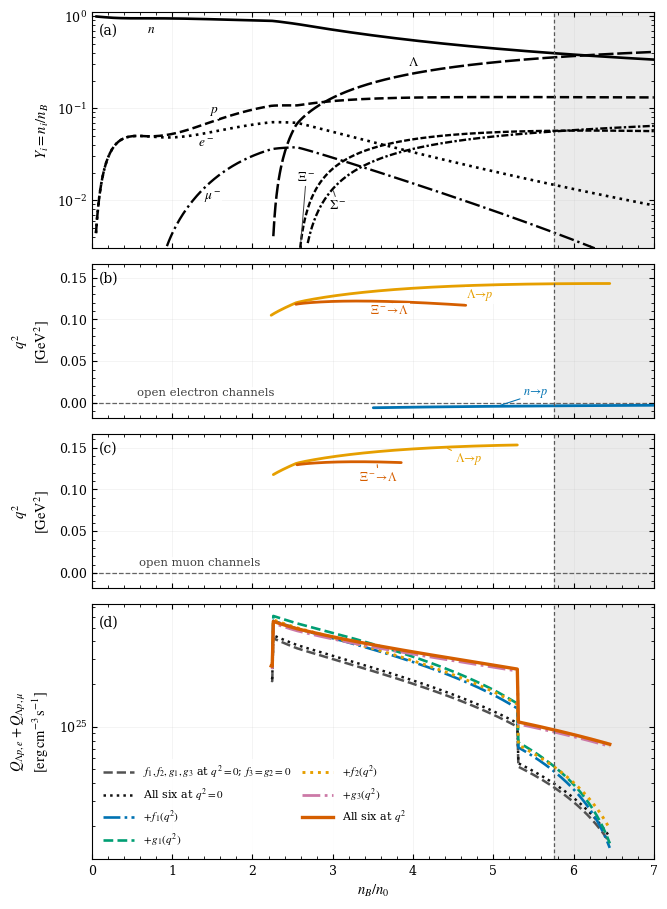

In [19]:
# ============================================================
# FIGURE 1 — Composition, q^2 kinematics, and progressive Lambda -> p
# ============================================================

from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# Progressive activation of form-factor q^2 dependence
# ============================================================

FF_FIELDS = ("f1", "f2", "f3", "g1", "g2", "g3")


PROGRESSIVE_FF_STAGES = OrderedDict([
    (
        "static_4",
        {
            "dynamic": set(),
            "forced_zero": {"f3", "g2"},
            "label": (
                r"$f_1(0),f_2(0),g_1(0),g_3(0)$; "
                r"$f_3=g_2=0$"
            ),
        },
    ),
    (
        "static_6",
        {
            "dynamic": set(),
            "forced_zero": set(),
            "label": r"all six at $q^2=0$",
        },
    ),
    (
        "q2_f1",
        {
            "dynamic": {"f1"},
            "forced_zero": set(),
            "label": r"$+\,f_1(q^2_{\rm kin})$",
        },
    ),
    (
        "q2_f1_g1",
        {
            "dynamic": {"f1", "g1"},
            "forced_zero": set(),
            "label": r"$+\,g_1(q^2_{\rm kin})$",
        },
    ),
    (
        "q2_f1_g1_f2",
        {
            "dynamic": {"f1", "g1", "f2"},
            "forced_zero": set(),
            "label": r"$+\,f_2(q^2_{\rm kin})$",
        },
    ),
    (
        "q2_f1_g1_f2_g3",
        {
            "dynamic": {"f1", "g1", "f2", "g3"},
            "forced_zero": set(),
            "label": r"$+\,g_3(q^2_{\rm kin})$",
        },
    ),
    (
        "full_q2",
        {
            "dynamic": set(FF_FIELDS),
            "forced_zero": set(),
            "label": r"all six at $q^2=q^2_{\rm kin}$",
        },
    ),
])
def _read_ff(ff, name):
    """Read a form factor from a dataclass/object or dictionary."""
    if hasattr(ff, name):
        return getattr(ff, name)

    if isinstance(ff, dict) and name in ff:
        return ff[name]

    legacy_names = {"f1": "F1V","f2": "F2V","f3": "F3V","g1": "F1A","g2": "F2A","g3": "F3A",}

    legacy = legacy_names[name]

    if isinstance(ff, dict) and legacy in ff:
        return ff[legacy]

    raise KeyError(f"Could not read form factor {name!r}.")


def _construct_ff_like(template, values):
    """Construct a new form-factor object of the same type."""
    try:
        return type(template)(**values)
    except TypeError:
        return FormFactors(**values)
def make_progressive_ff_getter(base_getter,target_channel,stage_name,):
    """
    Return a form-factor getter in which selected form factors
    are evaluated at q^2, while the others remain at q^2=0.

    The q^2 supplied by compute_emissivity is q^2_kin because
    that calculation is run with q2_mode="kinetic".
    """

    if stage_name not in PROGRESSIVE_FF_STAGES:
        raise ValueError(
            f"Unknown stage {stage_name!r}. "
            f"Available stages: {list(PROGRESSIVE_FF_STAGES)}"
        )

    stage = PROGRESSIVE_FF_STAGES[stage_name]
    dynamic = stage["dynamic"]
    forced_zero = stage["forced_zero"]

    def getter(channel, q2_MeV2, source="AUTO"):
        # Leave unrelated channels unchanged. The output is later
        # filtered to the requested target channel.
        if channel != target_channel:
            return base_getter(channel,q2_MeV2,source,)

        ff_zero = base_getter(channel,0.0,source,)

        ff_q2 = base_getter(channel,q2_MeV2,source,)

        values = {}

        for name in FF_FIELDS:
            if name in forced_zero:
                values[name] = 0.0
            elif name in dynamic:
                values[name] = _read_ff(ff_q2, name)
            else:
                values[name] = _read_ff(ff_zero, name)

        return _construct_ff_like( template=ff_zero,values=values,)

    return getter
def compute_progressive_ff_decomposition(eos_df,target_channel,lepton,base_getter=get_form_factors,source="AUTO",T9=1.0,):
    """
    Compute the cumulative q^2-dependence decomposition for
    one direct-Urca channel and one lepton.
    """

    results = OrderedDict()

    for stage_name in PROGRESSIVE_FF_STAGES:
        print(f"Computing {target_channel}, {lepton}: {stage_name}")

        staged_getter = make_progressive_ff_getter(base_getter=base_getter,target_channel=target_channel,stage_name=stage_name,)

        result = compute_emissivity(eos_df=eos_df,get_form_factors=staged_getter, source=source,q2_mode="kinetic",T9=T9,
            leptons=(lepton,),)

        selected = result[(result["channel"] == target_channel) & (result["lepton"] == lepton)].copy()

        selected = selected.sort_values("nB_over_n0").reset_index(drop=True)

        results[stage_name] = selected

    return results

# ============================================================
# 1. Compute Lambda -> p for electrons and muons
# ============================================================

lambda_p_e_progressive = compute_progressive_ff_decomposition(eos_df=df,target_channel="Lambda_to_p",lepton="e",source="AUTO",
    T9=1.0,)


lambda_p_mu_progressive = compute_progressive_ff_decomposition(eos_df=df,target_channel="Lambda_to_p",lepton="mu",source="AUTO",
    T9=1.0,)


# ============================================================
# 2. Combine electron + muon emissivities
# ============================================================

def combine_progressive_leptons(electron_results,muon_results,):
    """
    Combine electron and muon emissivities for each progressive
    form-factor stage.

        Q_total = Q_e + Q_mu

    If Q_obj is available, gvar correlations are retained.
    """

    combined = OrderedDict()

    for stage_name in PROGRESSIVE_FF_STAGES:

        e_df = electron_results[stage_name].copy()
        mu_df = muon_results[stage_name].copy()

        e_df = e_df.sort_values("nB_over_n0").reset_index(drop=True)
        mu_df = mu_df.sort_values("nB_over_n0").reset_index(drop=True)

        # Match rows by density rather than assuming identical indexing.
        merged = e_df.merge(mu_df,on="nB_over_n0",how="outer",suffixes=("_e", "_mu"),).sort_values("nB_over_n0")

        rows = []

        for _, row in merged.iterrows():

            x = float(row["nB_over_n0"])

            # ------------------------------------------------
            # Preserve gvar correlations where possible
            # ------------------------------------------------
            if (
                "Q_obj_e" in merged.columns
                and "Q_obj_mu" in merged.columns
            ):
                Qe = row["Q_obj_e"]
                Qmu = row["Q_obj_mu"]

                # Closed/missing channels contribute zero.
                if Qe is None or (
                    isinstance(Qe, float) and np.isnan(Qe)
                ):
                    Qe = 0.0

                if Qmu is None or (
                    isinstance(Qmu, float) and np.isnan(Qmu)
                ):
                    Qmu = 0.0

                Qtot = Qe + Qmu

                if gv is not None:
                    try:
                        q_mean = float(gv.mean(Qtot))
                        q_sdev = float(gv.sdev(Qtot))
                    except Exception:
                        q_mean = float(Qtot)
                        q_sdev = 0.0
                else:
                    q_mean = float(Qtot)
                    q_sdev = 0.0

            else:
                Qe = row.get("Q_mean_e", 0.0)
                Qmu = row.get("Q_mean_mu", 0.0)

                Qe = 0.0 if not np.isfinite(Qe) else float(Qe)
                Qmu = 0.0 if not np.isfinite(Qmu) else float(Qmu)

                q_mean = Qe + Qmu

                dQe = row.get("Q_sdev_e", 0.0)
                dQmu = row.get("Q_sdev_mu", 0.0)

                dQe = 0.0 if not np.isfinite(dQe) else float(dQe)
                dQmu = 0.0 if not np.isfinite(dQmu) else float(dQmu)

                # Fallback if Q_obj is unavailable.
                q_sdev = np.sqrt(
                    dQe**2 + dQmu**2
                )

            # Channel is active if either lepton channel is active.
            open_e = bool(row.get("open_e", False))
            open_mu = bool(row.get("open_mu", False))

            rows.append({"nB_over_n0": x,"Q_mean": q_mean, "Q_sdev": q_sdev, "open": open_e or open_mu,})

        combined[stage_name] = pd.DataFrame(rows)

    return combined


lambda_p_total_progressive = combine_progressive_leptons(electron_results=lambda_p_e_progressive, muon_results=lambda_p_mu_progressive,)


# ============================================================
# FOUR-PANEL PUBLICATION FIGURE
#
# (a) Particle fractions
# (b) q^2 for open electron direct-Urca channels
# (c) q^2 for open muon direct-Urca channels
# (d) Lambda -> p progressive form-factor decomposition
#
# Required variables already available in the notebook:
#   df                          EOS / direct-Urca dataframe
#   tov_df                      TOV sequence with M_Msun and nB_c_over_n0
#   lambda_p_total_progressive  OrderedDict of progressive Lambda -> p results
#   SAVE_OUTPUTS                optional Boolean
#
# The progressive result keys are expected to be:
#   static_4, static_6, q2_f1, q2_f1_g1,
#   q2_f1_g1_f2, q2_f1_g1_f2_g3, full_q2
# ============================================================

from collections import OrderedDict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Permanent styles
# ============================================================

CHANNEL_STYLE = OrderedDict([
    (
        "n_to_p",
        {
            "b1": "n",
            "b2": "p",
            "label": r"$n\to p$",
            "color": "#0072B2",
        },
    ),
    (
        "Lambda_to_p",
        {
            "b1": "Lambda",
            "b2": "p",
            "label": r"$\Lambda\to p$",
            "color": "#E69F00",
        },
    ),
    (
        "Sigma_minus_to_n",
        {
            "b1": "Sigma-",
            "b2": "n",
            "label": r"$\Sigma^-\to n$",
            "color": "#009E73",
        },
    ),
    (
        "Xi_minus_to_Lambda",
        {
            "b1": "Xi-",
            "b2": "Lambda",
            "label": r"$\Xi^-\to\Lambda$",
            "color": "#D55E00",
        },
    ),
    (
        "Xi_minus_to_Xi0",
        {
            "b1": "Xi-",
            "b2": "Xi0",
            "label": r"$\Xi^-\to\Xi^0$",
            "color": "#CC79A7",
        },
    ),
    (
        "Xi0_to_Sigma_plus",
        {
            "b1": "Xi0",
            "b2": "Sigma+",
            "label": r"$\Xi^0\to\Sigma^+$",
            "color": "#56B4E9",
        },
    ),
])

COMPOSITION_STYLE = OrderedDict([
    ("n",       {"label": r"$n$",         "ls": "-",                      "lw": 1.9}),
    ("p",       {"label": r"$p$",         "ls": "--",                     "lw": 1.8}),
    ("e",       {"label": r"$e^-$",       "ls": ":",                      "lw": 1.9}),
    ("mu",      {"label": r"$\mu^-$",     "ls": "-.",                     "lw": 1.7}),
    ("Lambda",  {"label": r"$\Lambda$",   "ls": (0, (6, 1.5)),            "lw": 1.8}),
    ("Sigma-",  {"label": r"$\Sigma^-$",  "ls": (0, (3, 1, 1, 1)),        "lw": 1.7}),
    ("Sigma0",  {"label": r"$\Sigma^0$",  "ls": (0, (1, 1)),              "lw": 1.6}),
    ("Sigma+",  {"label": r"$\Sigma^+$",  "ls": (0, (7, 2, 1, 2)),        "lw": 1.7}),
    ("Xi-",     {"label": r"$\Xi^-$",     "ls": (0, (2.5, 1)),            "lw": 1.7}),
    ("Xi0",     {"label": r"$\Xi^0$",     "ls": (0, (5, 1, 1, 1, 1, 1)), "lw": 1.7}),
])

# Positions used in the composition panel. The white boxes make
# the labels readable without hiding large portions of the curves.
COMPOSITION_LABEL_POSITIONS = {
    "n":       {"x": 0.70, "dx":  2, "dy": -8},
    "p":       {"x": 1.45, "dx":  4, "dy":  8},
    "e":       {"x": 1.45, "dx": -2, "dy":  -8},
    "mu":      {"x": 1.45, "dx":  3, "dy": -10},
    "Lambda":  {"x": 3.90, "dx":  6, "dy":  9},
    "Sigma-":  {"x": 3, "dx":  4, "dy": -12},
    "Sigma0":  {"x": 5.12, "dx": -2, "dy": -18},
    "Sigma+":  {"x": 6.45, "dx":  4, "dy":  7},
    "Xi-":     {"x": 2.6, "dx":  4, "dy":  48},
    "Xi0":     {"x": 6.52, "dx":  4, "dy": -9},
}

# Manual label positions for the q^2 panels. The label text is placed
# in axes-fraction coordinates and connected to the corresponding curve
# with a short leader line. This avoids label/curve overlap.
Q2_LABEL_CONFIG = {
    "e": {
        "Xi_minus_to_Lambda": {
            "anchor_x": 3.75,
            "text_axes": (0.53, 0.7),
        },
        "Lambda_to_p": {
            "anchor_x": 4.65,
            "text_axes": (0.69, 0.8),
        },
        "n_to_p": {
            "anchor_x": 5.05,
            "text_axes": (0.79, 0.16),
        },
    },
    "mu": {
        "Xi_minus_to_Lambda": {
            "anchor_x": 3.55,
            "text_axes": (0.51, 0.86),
        },
        "Lambda_to_p": {
            "anchor_x": 4.40,
            "text_axes": (0.67, 0.70),
        },
    },
}

Q2_LABEL_CONFIG2 = {
    "e": {
        "Xi_minus_to_Lambda": {
            "anchor_x": 3.75,
            "text_axes": (0.53, 0.7),
        },
        "Lambda_to_p": {
            "anchor_x": 4.65,
            "text_axes": (0.69, 0.8),
        },
        "n_to_p": {
            "anchor_x": 5.05,
            "text_axes": (0.79, 0.16),
        },
    },
    "mu": {
        "Xi_minus_to_Lambda": {
            "anchor_x": 3.55,
            "text_axes": (0.51, 0.72),
        },
        "Lambda_to_p": {
            "anchor_x": 4.40,
            "text_axes": (0.67, 0.84),
        },
    },
}

LAMBDA_PROGRESSIVE_STYLES = OrderedDict([
    (
        "static_4",
        {
            "color": "0.32",
            "linestyle": "--",
            "linewidth": 1.8,
        },
    ),
    (
        "static_6",
        {
            "color": "0.08",
            "linestyle": ":",
            "linewidth": 1.8,
        },
    ),
    (
        "q2_f1",
        {
            "color": "#0072B2",
            "linestyle": "-.",
            "linewidth": 1.9,
        },
    ),
    (
        "q2_f1_g1",
        {
            "color": "#009E73",
            "linestyle": "--",
            "linewidth": 1.9,
        },
    ),
    (
        "q2_f1_g1_f2",
        {
            "color": "#E69F00",
            "linestyle": ":",
            "linewidth": 2.1,
        },
    ),
    (
        "q2_f1_g1_f2_g3",
        {
            "color": "#CC79A7",
            "linestyle": "-.",
            "linewidth": 2.0,
        },
    ),
    (
        "full_q2",
        {
            "color": "#D55E00",
            "linestyle": "-",
            "linewidth": 2.4,
        },
    ),
])

# Safe MathText labels: single backslashes only.
LAMBDA_PROGRESSIVE_LABELS = {
    "static_4": r"$f_1,f_2,g_1,g_3$ at $q^2=0$; $f_3=g_2=0$",
    "static_6": r"All six at $q^2=0$",
    "q2_f1": r"$+\,f_1(q^2)$",
    "q2_f1_g1": r"$+\,g_1(q^2)$",
    "q2_f1_g1_f2": r"$+\,f_2(q^2)$",
    "q2_f1_g1_f2_g3": r"$+\,g_3(q^2)$",
    "full_q2": r"All six at $q^2$",
}


# ============================================================
# 2. Generic helpers
# ============================================================

def _maximum_mass_density(tov_df=None, explicit_value=None):
    if explicit_value is not None:
        return float(explicit_value)

    if tov_df is None:
        raise ValueError("Pass tov_df or max_mass_density_n0.")

    required = {"M_Msun", "nB_c_over_n0"}
    if not required.issubset(tov_df.columns):
        raise KeyError(
            "tov_df must contain 'M_Msun' and 'nB_c_over_n0'."
        )

    row = tov_df.loc[tov_df["M_Msun"].idxmax()]
    return float(row["nB_c_over_n0"])


def _shade_beyond_maximum_mass(ax, nc_max_n0, x_max):
    if x_max <= nc_max_n0:
        return

    ax.axvspan(
        nc_max_n0,
        x_max,
        color="0.92",
        zorder=-20,
    )
    ax.axvline(
        nc_max_n0,
        color="0.35",
        linestyle=(0, (3, 2)),
        linewidth=0.9,
        zorder=20,
    )


def _format_axis(ax, use_grid=True):
    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
    )
    ax.minorticks_on()

    if use_grid:
        ax.grid(
            True,
            which="major",
            linewidth=0.55,
            alpha=0.17,
        )


def _panel_label(ax, text):
    ax.text(
        0.012,
        0.955,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        zorder=50,
    )


def _curve_value_at_x(x, y, target_x):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(valid) < 2:
        return None

    xv = x[valid]
    yv = y[valid]

    order = np.argsort(xv)
    xv = xv[order]
    yv = yv[order]

    if target_x < xv[0] or target_x > xv[-1]:
        target_x = xv[np.argmin(np.abs(xv - target_x))]

    return float(np.interp(target_x, xv, yv))


def _annotate_curve_from_axes_fraction(
    ax,
    x,
    y,
    anchor_x,
    text_axes,
    text,
    color,
    fontsize=8.8,
):
    anchor_y = _curve_value_at_x(x, y, anchor_x)
    if anchor_y is None:
        return

    ax.annotate(
        text,
        xy=(anchor_x, anchor_y),
        xycoords="data",
        xytext=text_axes,
        textcoords="axes fraction",
        color=color,
        fontsize=fontsize,
        ha="center",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.88,
            "pad": 0.45,
        },
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "linewidth": 0.75,
            "shrinkA": 2.0,
            "shrinkB": 2.0,
        },
        annotation_clip=True,
        zorder=40,
    )


# ============================================================
# 3. Kinematic helpers
# ============================================================

def _triangle_factor(
    eos_df,
    channel_name,
    lepton,
    minimum_kf_MeV=1.0e-10,
):
    channel = CHANNEL_STYLE[channel_name]

    p1 = eos_df[f"kF_{channel['b1']}_MeV"].to_numpy(dtype=float)
    p2 = eos_df[f"kF_{channel['b2']}_MeV"].to_numpy(dtype=float)
    pl = eos_df[f"kF_{lepton}_MeV"].to_numpy(dtype=float)

    populated = (
        (p1 > minimum_kf_MeV)
        & (p2 > minimum_kf_MeV)
        & (pl > minimum_kf_MeV)
    )

    triangle = (
        (p2 + pl >= p1)
        & (p1 + pl >= p2)
        & (p1 + p2 >= pl)
    )

    return populated & triangle


def _q2_curve(eos_df,channel_name,lepton,open_only=True,):
    """
    Return q^2 = (epsilon_F1 - epsilon_F2)^2 - k_Fl^2 in GeV^2.
    """
    channel = CHANNEL_STYLE[channel_name]
    b1 = channel["b1"]
    b2 = channel["b2"]

    required = [
        "nB_over_n0",
        f"kF_{b1}_MeV",
        f"kF_{b2}_MeV",
        f"Mstar_{b1}_MeV",
        f"Mstar_{b2}_MeV",
        f"kF_{lepton}_MeV",
    ]
    missing = [col for col in required if col not in eos_df.columns]
    if missing:
        raise KeyError(
            f"Missing columns for {channel_name}, {lepton}: {missing}"
        )

    x = eos_df["nB_over_n0"].to_numpy(dtype=float)

    p1 = eos_df[f"kF_{b1}_MeV"].to_numpy(dtype=float)
    p2 = eos_df[f"kF_{b2}_MeV"].to_numpy(dtype=float)
    pl = eos_df[f"kF_{lepton}_MeV"].to_numpy(dtype=float)

    m1 = eos_df[f"Mstar_{b1}_MeV"].to_numpy(dtype=float)
    m2 = eos_df[f"Mstar_{b2}_MeV"].to_numpy(dtype=float)

    eps1 = np.sqrt(p1**2 + m1**2)
    eps2 = np.sqrt(p2**2 + m2**2)

    q2_GeV2 = ((eps1 - eps2) ** 2 - pl**2) * 1.0e-6

    if open_only:
        opened = _triangle_factor(
            eos_df=eos_df,
            channel_name=channel_name,
            lepton=lepton,
        )
        q2_GeV2 = np.where(opened, q2_GeV2, np.nan)

    return x, q2_GeV2


def _common_q2_limits(eos_df, leptons=("e", "mu")):
    values = []

    for lepton in leptons:
        for channel_name in CHANNEL_STYLE:
            _, q2 = _q2_curve(
                eos_df=eos_df,
                channel_name=channel_name,
                lepton=lepton,
                open_only=True,
            )
            valid = np.isfinite(q2)
            if np.any(valid):
                values.extend(q2[valid].tolist())

    if not values:
        return -0.1, 0.1

    qmin = float(np.min(values))
    qmax = float(np.max(values))
    span = max(qmax - qmin, 0.01)
    pad = 0.08 * span

    return qmin - pad, qmax + pad


def _plot_q2_panel(ax, eos_df, lepton):
    for channel_name, style in CHANNEL_STYLE.items():
        x, q2 = _q2_curve(
            eos_df=eos_df,
            channel_name=channel_name,
            lepton=lepton,
            open_only=True,
        )

        valid = np.isfinite(q2)
        if np.count_nonzero(valid) < 2:
            continue

        ax.plot(
            x,
            q2,
            color=style["color"],
            linewidth=2.0,
            solid_capstyle="round",
            zorder=5,
        )

        config = Q2_LABEL_CONFIG.get(lepton, {}).get(channel_name)
        if lepton!='e':
            config = Q2_LABEL_CONFIG2.get(lepton, {}).get(channel_name)
        if config is not None:
            _annotate_curve_from_axes_fraction(
                ax=ax,
                x=x,
                y=q2,
                anchor_x=config["anchor_x"],
                text_axes=config["text_axes"],
                text=style["label"],
                color=style["color"],
                fontsize=8.8,
            )

    ax.axhline(
        0.0,
        color="0.35",
        linestyle="--",
        linewidth=0.9,
        zorder=1,
    )


# ============================================================
# 4. Individual panel functions
# ============================================================

def _plot_composition_panel(
    ax,
    eos_df,
    composition_floor=3.0e-3,
    composition_ceiling=1.1,
):
    x = eos_df["nB_over_n0"].to_numpy(dtype=float)
    plotted = {}

    for species, style in COMPOSITION_STYLE.items():
        column = f"Y_{species}"
        if column not in eos_df.columns:
            continue

        y = eos_df[column].to_numpy(dtype=float)
        if (not np.any(np.isfinite(y))) or np.nanmax(y) <= 1.0e-10:
            continue

        y_plot = np.where(y >= composition_floor, y, np.nan)

        ax.plot(
            x,
            y_plot,
            color="black",
            linestyle=style["ls"],
            linewidth=style["lw"],
            solid_capstyle="round",
            zorder=5,
        )

        plotted[species] = y_plot

    for species, y_plot in plotted.items():
        position = COMPOSITION_LABEL_POSITIONS.get(species)
        if position is None:
            continue

        valid = np.isfinite(y_plot)
        if np.count_nonzero(valid) < 2:
            continue

        xv = x[valid]
        yv = y_plot[valid]
        x_label = position["x"]

        if not (xv.min() <= x_label <= xv.max()):
            continue

        y_label = np.interp(x_label, xv, yv)

        ax.annotate(
            COMPOSITION_STYLE[species]["label"],
            xy=(x_label, y_label),
            xytext=(position["dx"], position["dy"]),
            textcoords="offset points",
            color="black",
            fontsize=9.6,
            ha="center",
            va="center",
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.90,
                "pad": 0.35,
            },
            arrowprops=(
                {
                    "arrowstyle": "-",
                    "color": "0.25",
                    "linewidth": 0.7,
                    "shrinkA": 1.5,
                    "shrinkB": 1.5,
                }
                if species in {"Sigma-", "Xi-"}
                else None
            ),
            zorder=30,
        )

    ax.set_yscale("log")
    ax.set_ylim(composition_floor, composition_ceiling)
    ax.set_ylabel(r"$Y_i=n_i/n_B$")

    #ax.text(
    #    0.985,
    #    0.055,
    #    "particle fractions",
    #    transform=ax.transAxes,
    #    ha="right",
    #    va="bottom",
    #    fontsize=8.5,
    #    color="0.28",
    #    bbox={
    #        "facecolor": "white",
    #        "edgecolor": "none",
    #        "alpha": 0.78,
    #        "pad": 0.25,
    #    },
    #    zorder=40,
    #)

    _panel_label(ax, "(a)")
    _format_axis(ax, use_grid=True)


def _plot_lambda_progressive_panel(ax, results):
    for stage_name, data in results.items():
        if stage_name not in LAMBDA_PROGRESSIVE_STYLES:
            raise KeyError(
                f"No style defined for progressive stage {stage_name!r}."
            )
        if stage_name not in LAMBDA_PROGRESSIVE_LABELS:
            raise KeyError(
                f"No label defined for progressive stage {stage_name!r}."
            )

        style = LAMBDA_PROGRESSIVE_STYLES[stage_name]
        label = LAMBDA_PROGRESSIVE_LABELS[stage_name]

        data = data.sort_values("nB_over_n0").reset_index(drop=True)

        x = data["nB_over_n0"].to_numpy(dtype=float)
        q = data["Q_mean"].to_numpy(dtype=float)

        if "open" in data.columns:
            opened = data["open"].fillna(False).to_numpy(dtype=bool)
        else:
            opened = np.isfinite(q) & (q > 0.0)

        q_plot = np.where(
            opened & np.isfinite(q) & (q > 0.0),
            q,
            np.nan,
        )

        ax.plot(
            x,
            q_plot,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            label=label,
            zorder=6,
        )

        # Show the uncertainty band only for the full six-form-factor
        # momentum-dependent result.
        if stage_name == "full_q2" and "Q_sdev" in data.columns:
            dq = data["Q_sdev"].to_numpy(dtype=float)
            valid = (
                opened
                & np.isfinite(q)
                & np.isfinite(dq)
                & (q > 0.0)
            )

            lower = np.where(
                valid,
                np.maximum(q - dq, 1.0e-300),
                np.nan,
            )
            upper = np.where(valid, q + dq, np.nan)

            ax.fill_between(
                x,
                lower,
                upper,
                color=style["color"],
                alpha=0.14,
                linewidth=0.0,
                zorder=2,
            )

    ax.set_yscale("log")
    ax.set_ylabel(
        r"$Q_{\Lambda p,e}+Q_{\Lambda p,\mu}$"
        "\n"
        r"$[\mathrm{erg\,cm^{-3}\,s^{-1}}]$"
    )

    #ax.text(
    #    0.025,
    #    0.955,
    #    r"$\Lambda\to p$: progressive activation of the $q^2$ dependence",
    #    transform=ax.transAxes,
    #    ha="left",
    #    va="top",
    #    fontsize=8.5,
    #    bbox={
    #        "facecolor": "white",
    #        "edgecolor": "none",
    #        "alpha": 0.86,
    #        "pad": 0.35,
    #    },
    #    zorder=40,
    #)

    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="none",
        framealpha=0.88,
        ncol=2,
        loc="lower left",
        fontsize=8.0,
        handlelength=2.8,
        columnspacing=1.0,
        borderpad=0.45,
    )

    _panel_label(ax, "(d)")
    _format_axis(ax, use_grid=True)


# ============================================================
# 5. Main plotting function
# ============================================================

def plot_four_panel_lambda_progressive(
    eos_df,
    lambda_progressive_results,
    tov_df=None,
    max_mass_density_n0=None,
    x_min=0.0,
    x_max=7.0,
    composition_floor=3.0e-3,
    composition_ceiling=1.1,
    save_outputs=True,
    output_prefix="fsu2h_four_panel_lambda_progressive",
    show=True,
):
    nc_max_n0 = _maximum_mass_density(
        tov_df=tov_df,
        explicit_value=max_mass_density_n0,
    )

    q2_limits = _common_q2_limits(eos_df=eos_df)

    publication_rc = {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 9.5,
        "axes.labelsize": 10.5,
        "axes.titlesize": 10.5,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8.2,
        "axes.linewidth": 0.8,
        "savefig.dpi": 600,
    }

    with plt.rc_context(publication_rc):
        fig, axes = plt.subplots(
            4,
            1,
            figsize=(7.25, 11.0),
            sharex=True,
            gridspec_kw={
                "height_ratios": [2.45, 1.60, 1.60, 2.65],
                "hspace": 0.08,
            },
        )

        ax_comp, ax_q2_e, ax_q2_mu, ax_lambda = axes

        # ----------------------------------------------------
        # (a) Composition
        # ----------------------------------------------------
        _plot_composition_panel(
            ax=ax_comp,
            eos_df=eos_df,
            composition_floor=composition_floor,
            composition_ceiling=composition_ceiling,
        )

        #ax_comp.text(
        #    nc_max_n0 - 0.05,
        #    0.90,
        #    r"$n_c(M_{\rm max})$",
        #    transform=ax_comp.get_xaxis_transform(),
        #    rotation=90,
        #    ha="right",
        #    va="top",
        #    fontsize=8,
        #    color="0.30",
        #    zorder=40,
        #)

        # ----------------------------------------------------
        # (b) Electron-channel q^2
        # ----------------------------------------------------
        _plot_q2_panel(
            ax=ax_q2_e,
            eos_df=eos_df,
            lepton="e",
        )
        ax_q2_e.set_ylim(*q2_limits)
        ax_q2_e.set_ylabel(r"$q^2$" "\n" r"$[\mathrm{GeV}^2]$")
        ax_q2_e.text(
            0.325,
            0.2,
            "open electron channels",
            transform=ax_q2_e.transAxes,
            ha="right",
            va="top",
            fontsize=8.4,
            color="0.25",
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.84,
                "pad": 0.25,
            },
            zorder=40,
        )
        _panel_label(ax_q2_e, "(b)")
        _format_axis(ax_q2_e, use_grid=True)

        # ----------------------------------------------------
        # (c) Muon-channel q^2
        # ----------------------------------------------------
        _plot_q2_panel(
            ax=ax_q2_mu,
            eos_df=eos_df,
            lepton="mu",
        )
        ax_q2_mu.set_ylim(*q2_limits)
        ax_q2_mu.set_ylabel(r"$q^2$" "\n" r"$[\mathrm{GeV}^2]$")
        ax_q2_mu.text(
            0.3,
            0.2,
            "open muon channels",
            transform=ax_q2_mu.transAxes,
            ha="right",
            va="top",
            fontsize=8.4,
            color="0.25",
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.84,
                "pad": 0.25,
            },
            zorder=40,
        )
        _panel_label(ax_q2_mu, "(c)")
        _format_axis(ax_q2_mu, use_grid=True)

        # ----------------------------------------------------
        # (d) Progressive Lambda -> p emissivity
        # ----------------------------------------------------
        _plot_lambda_progressive_panel(
            ax=ax_lambda,
            results=lambda_progressive_results,
        )
        ax_lambda.set_xlabel(r"$n_B/n_0$")

        # ----------------------------------------------------
        # Shared density range and stable-star shading
        # ----------------------------------------------------
        for axis in axes:
            axis.set_xlim(x_min, x_max)
            _shade_beyond_maximum_mass(
                ax=axis,
                nc_max_n0=nc_max_n0,
                x_max=x_max,
            )

        ax_lambda.set_xticks(
            np.arange(
                np.ceil(x_min),
                np.floor(x_max) + 1.0,
                1.0,
            )
        )

        for axis in axes[:-1]:
            axis.tick_params(labelbottom=False)

        fig.align_ylabels(axes)

        if save_outputs:
            output_path = Path(output_prefix)
            fig.savefig(
                output_path.with_suffix(".pdf"),
                bbox_inches="tight",
            )
            fig.savefig(
                output_path.with_suffix(".png"),
                dpi=600,
                bbox_inches="tight",
            )

        if show:
            plt.show()

        return fig, axes


# ============================================================
# 6. Run
# ============================================================

fig_four_panel, axes_four_panel = plot_four_panel_lambda_progressive(
    eos_df=df,
    lambda_progressive_results=lambda_p_total_progressive,
    tov_df=tov_df,
    x_min=0.0,
    x_max=7.0,
    save_outputs=globals().get("SAVE_OUTPUTS", True),
    output_prefix="fsu2h_four_panel_lambda_progressive",
    show=True,
)


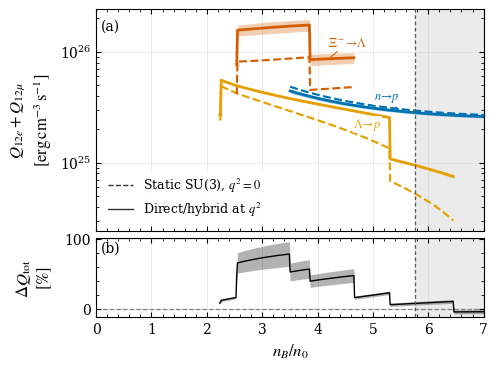

In [6]:
# ============================================================
# FIGURE 2 — Channel emissivities and total relative correction
# ============================================================

# ============================================================
# TWO-PANEL PUBLICATION FIGURE
#
# (a) Individual direct-Urca channel emissivities,
#     summed over electron and muon channels
#
# (b) Total relative correction only
#
# Required variables already available in the notebook:
#   res_su3_0       static SU(3), q^2 = 0
#   res_prod_qkin   direct/hybrid evaluated at q^2
#   tov_df          TOV sequence with M_Msun and nB_c_over_n0
#   SAVE_OUTPUTS    optional Boolean
# ============================================================

from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    import gvar as gv
except ImportError:
    gv = None


# ============================================================
# 1. Permanent styles
# ============================================================

CHANNEL_STYLE = OrderedDict([
    (
        "n_to_p",
        {
            "label": r"$n\to p$",
            "color": "#0072B2",
        },
    ),
    (
        "Lambda_to_p",
        {
            "label": r"$\Lambda\to p$",
            "color": "#E69F00",
        },
    ),
    (
        "Sigma_minus_to_n",
        {
            "label": r"$\Sigma^-\to n$",
            "color": "#009E73",
        },
    ),
    (
        "Xi_minus_to_Lambda",
        {
            "label": r"$\Xi^-\to\Lambda$",
            "color": "#D55E00",
        },
    ),
    (
        "Xi_minus_to_Xi0",
        {
            "label": r"$\Xi^-\to\Xi^0$",
            "color": "#CC79A7",
        },
    ),
    (
        "Xi0_to_Sigma_plus",
        {
            "label": r"$\Xi^0\to\Sigma^+$",
            "color": "#56B4E9",
        },
    ),
])

# Manual label positions in the upper panel. The text positions are
# given in axes-fraction coordinates; anchor_x identifies the point on
# the solid curve connected to the label by a leader line.
CHANNEL_LABEL_CONFIG = {
    "Xi_minus_to_Lambda": {
        "anchor_x": 4.2,
        "text_axes": (0.65, 0.85),
    },
    "Lambda_to_p": {
        "anchor_x": 5.05,
        "text_axes": (0.7, 0.48),
    },
    "n_to_p": {
        "anchor_x": 5.5,
        "text_axes": (0.75, 0.6),
    },
}
# ============================================================
# 2. Generic helpers
# ============================================================

def _result_x_column(result):
    for column in ("nB_over_n0", "x"):
        if column in result.columns:
            return column

    raise KeyError(
        "Result table must contain 'nB_over_n0' or 'x'."
    )


def _scalar_mean_sdev(value):
    if gv is not None:
        try:
            return float(gv.mean(value)), float(gv.sdev(value))
        except Exception:
            pass

    return float(value), 0.0


def _aggregate_emissivity(result, by_channel=True):
    """
    Sum electron and muon contributions while preserving gvar
    correlations.

    Returns
    -------
    DataFrame with:
        x
        channel (when by_channel=True)
        Q_obj
        Q_mean
        Q_sdev

    Q_obj is retained so that later ratios and sums can be formed from
    the correlated gvar objects rather than from means and standard
    deviations treated as independent numbers.
    """
    x_column = _result_x_column(result)

    group_columns = [x_column]
    if by_channel:
        group_columns.append("channel")

    rows = []

    for key, group in result.groupby(group_columns, sort=True):
        if by_channel:
            x_value, channel = key
        else:
            x_value = key[0] if isinstance(key, tuple) else key
            channel = None

        if "Q_obj" in group.columns:
            total = 0.0

            for obj in group["Q_obj"].to_numpy(dtype=object):
                if obj is None:
                    continue

                if isinstance(obj, (float, np.floating)) and np.isnan(obj):
                    continue

                total = total + obj

            q_obj = total
            q_mean, q_sdev = _scalar_mean_sdev(q_obj)

        else:
            # Fallback only. The production emissivity tables contain
            # Q_obj, so the correlated branch above should normally be used.
            q_mean = float(
                np.nansum(group["Q_mean"].to_numpy(dtype=float))
            )

            if "Q_sdev" in group.columns:
                q_sdev = float(
                    np.sqrt(
                        np.nansum(
                            group["Q_sdev"].to_numpy(dtype=float) ** 2
                        )
                    )
                )
            else:
                q_sdev = 0.0

            if gv is not None and q_sdev > 0.0:
                q_obj = gv.gvar(q_mean, q_sdev)
            else:
                q_obj = q_mean

        row = {
            "x": float(x_value),
            "Q_obj": q_obj,
            "Q_mean": q_mean,
            "Q_sdev": q_sdev,
        }

        if by_channel:
            row["channel"] = channel

        rows.append(row)

    return pd.DataFrame(rows)

def _maximum_mass_density(tov_df=None, explicit_value=None):
    if explicit_value is not None:
        return float(explicit_value)

    if tov_df is None:
        raise ValueError("Pass tov_df or max_mass_density_n0.")

    required = {"M_Msun", "nB_c_over_n0"}
    if not required.issubset(tov_df.columns):
        raise KeyError(
            "tov_df must contain 'M_Msun' and 'nB_c_over_n0'."
        )

    row = tov_df.loc[tov_df["M_Msun"].idxmax()]
    return float(row["nB_c_over_n0"])


def _shade_beyond_maximum_mass(ax, nc_max_n0, x_max):
    if x_max <= nc_max_n0:
        return

    ax.axvspan(
        nc_max_n0,
        x_max,
        color="0.92",
        zorder=-20,
    )
    ax.axvline(
        nc_max_n0,
        color="0.35",
        linestyle=(0, (3, 2)),
        linewidth=0.9,
        zorder=20,
    )


def _panel_label(ax, text):
    ax.text(
        0.012,
        0.955,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        zorder=50,
    )


def _curve_value_at_x(x, y, target_x):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(valid) < 2:
        return None

    xv = x[valid]
    yv = y[valid]

    order = np.argsort(xv)
    xv = xv[order]
    yv = yv[order]

    if target_x < xv[0] or target_x > xv[-1]:
        target_x = xv[np.argmin(np.abs(xv - target_x))]

    return float(np.interp(target_x, xv, yv))


def _annotate_channel_curve(
    ax,
    x,
    y,
    anchor_x,
    text_axes,
    text,
    color,
    fontsize=8.9,
):
    anchor_y = _curve_value_at_x(x, y, anchor_x)
    if anchor_y is None:
        return

    ax.annotate(
        text,
        xy=(anchor_x, anchor_y),
        xycoords="data",
        xytext=text_axes,
        textcoords="axes fraction",
        color=color,
        fontsize=fontsize,
        ha="center",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.90,
            "pad": 0.45,
        },
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "linewidth": 0.8,
            "shrinkA": 2.0,
            "shrinkB": 2.0,
        },
        annotation_clip=True,
        zorder=40,
    )


def _percentage_difference(
    su3_data,
    hybrid_data,
    ratio_floor_fraction=1.0e-7,
):
    """
    Correlated relative correction

        Delta Q = 100 * (Q_hybrid - Q_SU3) / Q_SU3.

    The operation is performed on Q_obj whenever available, so the
    uncertainty and all gvar correlations are propagated through the
    ratio.

    Returns a DataFrame with:
        x
        percentage_obj
        percentage_mean
        percentage_sdev
    """
    merged = su3_data.merge(
        hybrid_data,
        on="x",
        how="inner",
        suffixes=("_su3", "_hybrid"),
    ).sort_values("x").reset_index(drop=True)

    denominator_mean = merged["Q_mean_su3"].to_numpy(dtype=float)

    scale = np.nanmax(np.abs(denominator_mean))
    threshold = (
        ratio_floor_fraction * scale
        if np.isfinite(scale) and scale > 0.0
        else np.inf
    )

    rows = []

    for _, row in merged.iterrows():
        x_value = float(row["x"])
        denom_mean = float(row["Q_mean_su3"])

        if not np.isfinite(denom_mean) or denom_mean <= threshold:
            rows.append({
                "x": x_value,
                "percentage_obj": np.nan,
                "percentage_mean": np.nan,
                "percentage_sdev": np.nan,
            })
            continue

        q_su3 = (
            row["Q_obj_su3"]
            if "Q_obj_su3" in merged.columns
            else row["Q_mean_su3"]
        )
        q_hybrid = (
            row["Q_obj_hybrid"]
            if "Q_obj_hybrid" in merged.columns
            else row["Q_mean_hybrid"]
        )

        percentage_obj = 100.0 * (q_hybrid - q_su3) / q_su3
        percentage_mean, percentage_sdev = _scalar_mean_sdev(
            percentage_obj
        )

        rows.append({
            "x": x_value,
            "percentage_obj": percentage_obj,
            "percentage_mean": percentage_mean,
            "percentage_sdev": percentage_sdev,
        })

    return pd.DataFrame(rows)

# ============================================================
# 3. Main plotting function
# ============================================================

def plot_channel_emissivities_with_total_ratio(
    result_su3,
    result_hybrid,
    tov_df=None,
    max_mass_density_n0=None,
    x_min=0.0,
    x_max=7.0,
    ratio_floor_fraction=1.0e-7,
    show_uncertainty=True,
    save_outputs=True,
    output_prefix="channel_emissivities_total_ratio",
    show=True,
):
    nc_max_n0 = _maximum_mass_density(
        tov_df=tov_df,
        explicit_value=max_mass_density_n0,
    )

    # Sum e + mu separately for every transition.
    su3_channel = _aggregate_emissivity(
        result_su3,
        by_channel=True,
    )
    hybrid_channel = _aggregate_emissivity(
        result_hybrid,
        by_channel=True,
    )

    # Sum over every transition and both charged leptons.
    su3_total = _aggregate_emissivity(
        result_su3,
        by_channel=False,
    )
    hybrid_total = _aggregate_emissivity(
        result_hybrid,
        by_channel=False,
    )

    ratio_df = _percentage_difference(
        su3_data=su3_total,
        hybrid_data=hybrid_total,
        ratio_floor_fraction=ratio_floor_fraction,
    )

    x_ratio = ratio_df["x"].to_numpy(dtype=float)
    total_percentage = ratio_df["percentage_mean"].to_numpy(dtype=float)
    total_percentage_sdev = ratio_df["percentage_sdev"].to_numpy(dtype=float)

    publication_rc = {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.linewidth": 0.8,
        "savefig.dpi": 600,
    }

    with plt.rc_context(publication_rc):
        fig, (ax_q, ax_ratio) = plt.subplots(
            2,
            1,
            figsize=(5.0, 4.0),
            sharex=True,
            gridspec_kw={
                "height_ratios": [3.2, 1.15],
                "hspace": 0.05,
            },
        )

        # ====================================================
        # (a) Individual channel emissivities
        # ====================================================
        for channel_name, style in CHANNEL_STYLE.items():
            su3_curve = su3_channel[
                su3_channel["channel"].eq(channel_name)
            ].sort_values("x")

            hybrid_curve = hybrid_channel[
                hybrid_channel["channel"].eq(channel_name)
            ].sort_values("x")

            if su3_curve.empty and hybrid_curve.empty:
                continue

            # Static SU(3), q^2 = 0.
            if not su3_curve.empty:
                x_su3 = su3_curve["x"].to_numpy(dtype=float)
                y_su3 = su3_curve["Q_mean"].to_numpy(dtype=float)

                y_su3_plot = np.where(
                    np.isfinite(y_su3) & (y_su3 > 0.0),
                    y_su3,
                    np.nan,
                )

                ax_q.plot(
                    x_su3,
                    y_su3_plot,
                    color=style["color"],
                    linestyle="--",
                    linewidth=1.55,
                    zorder=5,
                )

            # Direct/hybrid evaluated at q^2.
            if not hybrid_curve.empty:
                x_hybrid = hybrid_curve["x"].to_numpy(dtype=float)
                y_hybrid = hybrid_curve["Q_mean"].to_numpy(dtype=float)

                if "Q_sdev" in hybrid_curve.columns:
                    dy_hybrid = hybrid_curve[
                        "Q_sdev"
                    ].to_numpy(dtype=float)
                else:
                    dy_hybrid = np.zeros_like(y_hybrid)

                y_hybrid_plot = np.where(
                    np.isfinite(y_hybrid) & (y_hybrid > 0.0),
                    y_hybrid,
                    np.nan,
                )

                ax_q.plot(
                    x_hybrid,
                    y_hybrid_plot,
                    color=style["color"],
                    linestyle="-",
                    linewidth=2.0,
                    zorder=8,
                )

                if show_uncertainty:
                    band_mask = (
                        np.isfinite(y_hybrid_plot)
                        & np.isfinite(dy_hybrid)
                        & (dy_hybrid > 0.0)
                    )

                    if np.any(band_mask):
                        lower = np.maximum(
                            y_hybrid - dy_hybrid,
                            1.0e-300,
                        )
                        upper = y_hybrid + dy_hybrid

                        ax_q.fill_between(
                            x_hybrid,
                            np.where(band_mask, lower, np.nan),
                            np.where(band_mask, upper, np.nan),
                            color=style["color"],
                            alpha=0.3,
                            linewidth=0.0,
                            zorder=3,
                        )

                label_config = CHANNEL_LABEL_CONFIG.get(channel_name)
                if label_config is not None:
                    _annotate_channel_curve(
                        ax=ax_q,
                        x=x_hybrid,
                        y=y_hybrid_plot,
                        anchor_x=label_config["anchor_x"],
                        text_axes=label_config["text_axes"],
                        text=style["label"],
                        color=style["color"],
                        fontsize=8.9,
                    )

        ax_q.set_yscale("log")
        ax_q.set_ylabel(
            r"$Q_{12e}+Q_{12\mu}$"
            "\n"
            r"$[\mathrm{erg\,cm^{-3}\,s^{-1}}]$"
        )
        #ax_q.set_title(
        #    "Individual direct-Urca channel emissivities",
        #    loc="left",
        #    pad=6,
        #)

        # The legend explains the line-style convention only.
        style_legend = [
            Line2D(
                [0],
                [0],
                color="0.20",
                linestyle="--",
                linewidth=1,
                label=r"Static SU(3), $q^2=0$",
            ),
            Line2D(
                [0],
                [0],
                color="0.20",
                linestyle="-",
                linewidth=1,
                label=r"Direct/hybrid at $q^2$",
            ),
        ]

        ax_q.legend(
            handles=style_legend,
            frameon=True,
            facecolor="white",
            edgecolor="none",
            framealpha=0.90,
            loc="lower left",
            borderpad=0.45,
        )

        _panel_label(ax_q, "(a)")

        # ====================================================
        # (b) Total relative correction only
        # ====================================================
        ax_ratio.plot(
            x_ratio,
            total_percentage,
            color="black",
            linewidth=1,
            zorder=10,
        )

        if show_uncertainty:
            ratio_band_mask = (
                np.isfinite(total_percentage)
                & np.isfinite(total_percentage_sdev)
                & (total_percentage_sdev > 0.0)
            )

            if np.any(ratio_band_mask):
                ax_ratio.fill_between(
                    x_ratio,
                    np.where(
                        ratio_band_mask,
                        total_percentage - total_percentage_sdev,
                        np.nan,
                    ),
                    np.where(
                        ratio_band_mask,
                        total_percentage + total_percentage_sdev,
                        np.nan,
                    ),
                    color="black",
                    alpha=0.3,
                    linewidth=0.0,
                    zorder=3,
                )

        ax_ratio.axhline(
            0.0,
            color="0.45",
            linestyle="--",
            linewidth=0.9,
            zorder=1,
        )

        ax_ratio.set_ylabel(
            r"$\Delta Q_{\rm tot}$"
            "\n"
            r"$[\%]$"
        )
        ax_ratio.set_xlabel(r"$n_B/n_0$")

        #ax_ratio.text(
        #    0.025,
        #    0.88,
        #    r"$\Delta Q_{\rm tot}="
        #    r"100\,(Q_{\rm SU(3)}-Q_{\rm lat/hyb})"
        #    r"/Q_{\rm SU(3)}$"
        #    "\n"
        #    r"negative values: lattice-informed enhancement",
        #    transform=ax_ratio.transAxes,
        #    fontsize=8.3,
        #    ha="left",
        #    va="top",
        #    bbox={
        #        "facecolor": "white",
        #        "edgecolor": "none",
        #        "alpha": 0.88,
        #        "pad": 0.35,
        #    },
        #    zorder=40,
        #)

        _panel_label(ax_ratio, "(b)")

        # ====================================================
        # Shared formatting
        # ====================================================
        for axis in (ax_q, ax_ratio):
            axis.set_xlim(x_min, x_max)

            _shade_beyond_maximum_mass(
                ax=axis,
                nc_max_n0=nc_max_n0,
                x_max=x_max,
            )

            axis.grid(
                True,
                which="major",
                linewidth=0.55,
                alpha=0.3,
            )

            axis.tick_params(
                which="both",
                direction="in",
                top=True,
                right=True,
            )
            axis.minorticks_on()

        ax_ratio.set_xticks(
            np.arange(
                np.ceil(x_min),
                np.floor(x_max) + 1.0,
                1.0,
            )
        )

        fig.align_ylabels([ax_q, ax_ratio])

        if save_outputs:
            output_path = Path(output_prefix)
            fig.savefig(
                output_path.with_suffix(".pdf"),
                bbox_inches="tight",
            )
            fig.savefig(
                output_path.with_suffix(".png"),
                dpi=600,
                bbox_inches="tight",
            )

        if show:
            plt.show()

        return fig, (ax_q, ax_ratio)


# ============================================================
# 4. Run
# ============================================================

fig_emissivity, axes_emissivity = (
    plot_channel_emissivities_with_total_ratio(
        result_su3=res_su3_0,
        result_hybrid=res_prod_qkin,
        tov_df=tov_df,
        x_min=0.0,
        x_max=7.0,
        save_outputs=globals().get("SAVE_OUTPUTS", True),
        output_prefix="channel_emissivities_total_ratio",
        show=True,
    )
)


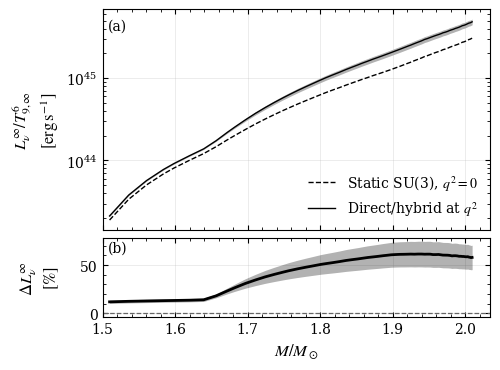

In [7]:
# ============================================================
# FIGURE 3 — Redshifted neutrino luminosity
# ============================================================

# ============================================================
# Neutrino luminosity at infinity:
#
#     L_nu^inf / T^6
#
# One-panel plot versus stellar mass or central density.
#
# Required existing variables:
#   res_su3_0      : static SU(3), q^2 = 0 emissivity result
#   res_prod_qkin  : direct/hybrid, q^2 = q_kin^2 emissivity result
#   tov_profiles   : list of radial-profile DataFrames
#
# Each profile DataFrame should contain at least:
#   r_km  or r_cm
#   m_Msun or m_g
#   phi
#   nB_over_n0
#
# Preferably also:
#   M_Msun
#   nB_c_over_n0
#
# This cell assumes your emissivities were computed at T9 = 1.
# Therefore the integrated result is L_nu^inf / T9^6.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import gvar as gv
except ImportError:
    gv = None


# ============================================================
# Constants (cgs)
# ============================================================

G_CGS = 6.67430e-8
C_CGS = 2.99792458e10
MSUN_CGS = 1.98847e33
KM_TO_CM = 1.0e5


# ============================================================
# 1. Helpers for emissivity aggregation
# ============================================================


def _scalar_mean_sdev(value):
    if gv is not None:
        try:
            return float(gv.mean(value)), float(gv.sdev(value))
        except Exception:
            pass
    return float(value), 0.0


def _result_x_column(result):
    for col in ("nB_over_n0", "x"):
        if col in result.columns:
            return col
    raise KeyError("Result must contain 'nB_over_n0' or 'x'.")


def _aggregate_total_emissivity(result):
    """
    Sum all channels and leptons at each density point while preserving
    the correlated gvar object.

    Returns DataFrame with:
        x, Q_obj, Q_mean, Q_sdev
    """
    xcol = _result_x_column(result)
    rows = []

    for xval, group in result.groupby(xcol, sort=True):
        if "Q_obj" in group.columns and gv is not None:
            total = 0.0

            for obj in group["Q_obj"].to_numpy(dtype=object):
                if obj is None:
                    continue

                if isinstance(obj, (float, np.floating)) and np.isnan(obj):
                    continue

                total = total + obj

            q_obj = total
            q_mean = float(gv.mean(q_obj))
            q_sdev = float(gv.sdev(q_obj))

        else:
            q_mean = float(
                np.nansum(group["Q_mean"].to_numpy(dtype=float))
            )

            if "Q_sdev" in group.columns:
                q_sdev = float(
                    np.sqrt(
                        np.nansum(
                            group["Q_sdev"].to_numpy(dtype=float) ** 2
                        )
                    )
                )
            else:
                q_sdev = 0.0

            if gv is not None and q_sdev > 0.0:
                q_obj = gv.gvar(q_mean, q_sdev)
            else:
                q_obj = q_mean

        rows.append({
            "x": float(xval),
            "Q_obj": q_obj,
            "Q_mean": q_mean,
            "Q_sdev": q_sdev,
        })

    return pd.DataFrame(rows).sort_values("x").reset_index(drop=True)

def build_emissivity_interpolator(result):
    """
    Build a correlation-preserving piecewise-linear interpolator for
    Q_total(x), where x = nB/n0.

    Interpolation is performed directly on Q_obj. Since every density
    point is ultimately a function of the same underlying gvar fit
    parameters, this retains correlations between different densities
    and between different channels.

    Returns
    -------
    interp_function
        Accepts scalar or array x and returns gvar/float values.
    total_df
        x, Q_obj, Q_mean, Q_sdev.
    """
    total_df = _aggregate_total_emissivity(result)

    x_grid = total_df["x"].to_numpy(dtype=float)

    if "Q_obj" in total_df.columns:
        q_grid = total_df["Q_obj"].to_numpy(dtype=object)
    else:
        q_grid = total_df["Q_mean"].to_numpy(dtype=object)

    def interp(x_new):
        scalar_input = np.ndim(x_new) == 0
        x_new_arr = np.atleast_1d(np.asarray(x_new, dtype=float))

        out = np.empty(x_new_arr.shape, dtype=object)

        for index, value in np.ndenumerate(x_new_arr):
            if (
                not np.isfinite(value)
                or value < x_grid[0]
                or value > x_grid[-1]
            ):
                out[index] = 0.0
                continue

            j = np.searchsorted(x_grid, value, side="right") - 1

            if j < 0:
                out[index] = 0.0
            elif j >= len(x_grid) - 1:
                out[index] = q_grid[-1]
            else:
                x0 = x_grid[j]
                x1 = x_grid[j + 1]

                if x1 == x0:
                    out[index] = q_grid[j]
                else:
                    t = (value - x0) / (x1 - x0)
                    out[index] = (
                        (1.0 - t) * q_grid[j]
                        + t * q_grid[j + 1]
                    )

        if scalar_input:
            return out.flat[0]

        return out

    return interp, total_df

# ============================================================
# 2. Helpers for TOV profile handling
# ============================================================

def _get_radius_cm(profile):
    if "r_cm" in profile.columns:
        return profile["r_cm"].to_numpy(dtype=float)
    if "r_km" in profile.columns:
        return profile["r_km"].to_numpy(dtype=float) * KM_TO_CM
    raise KeyError("Profile needs 'r_cm' or 'r_km'.")


def _get_mass_g(profile):
    if "m_g" in profile.columns:
        return profile["m_g"].to_numpy(dtype=float)
    if "m_Msun" in profile.columns:
        return profile["m_Msun"].to_numpy(dtype=float) * MSUN_CGS
    raise KeyError("Profile needs 'm_g' or 'm_Msun'.")


def _get_phi(profile):
    for col in ("phi", "Phi", "metric_phi"):
        if col in profile.columns:
            return profile[col].to_numpy(dtype=float)
    raise KeyError(
        "Profile needs a metric potential column like 'phi'."
    )


def _get_nb_ratio(profile):
    if "nB_over_n0" in profile.columns:
        return profile["nB_over_n0"].to_numpy(dtype=float)
    raise KeyError("Profile needs 'nB_over_n0'.")


def _get_star_mass(profile):
    """
    Get the stellar gravitational mass in solar masses.
    Prefer summary column if present; otherwise use last profile point.
    """
    if "M_Msun" in profile.columns:
        vals = profile["M_Msun"].to_numpy(dtype=float)
        if np.isfinite(vals[0]):
            return float(vals[0])
    if "m_Msun" in profile.columns:
        vals = profile["m_Msun"].to_numpy(dtype=float)
        return float(vals[-1])
    if "m_g" in profile.columns:
        vals = profile["m_g"].to_numpy(dtype=float)
        return float(vals[-1] / MSUN_CGS)
    raise KeyError("Could not infer star mass from profile.")


def _get_central_density_ratio(profile):
    """
    Get central density nB_c / n0.
    Prefer summary column if present; otherwise use first profile point.
    """
    if "nB_c_over_n0" in profile.columns:
        vals = profile["nB_c_over_n0"].to_numpy(dtype=float)
        if np.isfinite(vals[0]):
            return float(vals[0])

    nb = _get_nb_ratio(profile)
    return float(nb[0])


# ============================================================
# 3. Luminosity integral
# ============================================================

def integrate_lnu_infinity_over_profile(
    profile,
    q_tilde_interp,
    temperature_mode="redshifted_isothermal",
):
    """
    Integrate L_nu^infinity / T9^6 over one star.

    The emissivity interpolation may return correlated gvar objects.
    The radial integral is therefore carried out without converting the
    integrand to float, preserving form-factor uncertainty and its
    correlations across radius.

    Returns
    -------
    luminosity_div_T9_6
        float or gvar, in erg/s.
    """
    prof = profile.copy()

    r = _get_radius_cm(prof)
    m = _get_mass_g(prof)
    phi = _get_phi(prof)
    x = _get_nb_ratio(prof)

    order = np.argsort(r)
    r = r[order]
    m = m[order]
    phi = phi[order]
    x = x[order]

    q_tilde = np.asarray(q_tilde_interp(x), dtype=object)

    r_safe = np.where(r > 0.0, r, np.nan)

    compactness = 2.0 * G_CGS * m / (r_safe * C_CGS**2)
    compactness = np.where(np.isfinite(compactness),compactness,0.0,)

    denom = np.sqrt(np.maximum(1.0 - compactness, 1.0e-14))

    if temperature_mode == "redshifted_isothermal":
        # T9(r) = T9_inf exp(-phi)
        # L_inf/T9_inf^6 = int dV Qtilde exp(-4 phi)
        temp_factor = np.exp(-4.0 * phi)

    elif temperature_mode == "local_isothermal":
        # L_inf/T9^6 = int dV Qtilde exp(+2 phi)
        temp_factor = np.exp(2.0 * phi)

    else:
        raise ValueError(
            "temperature_mode must be "
            "'redshifted_isothermal' or 'local_isothermal'."
        )

    weight = (4.0* np.pi* r**2 * temp_factor / denom)

    integrand = q_tilde * weight

    # Correlation-preserving trapezoidal integral.
    luminosity = 0.0

    for i in range(len(r) - 1):
        dr = r[i + 1] - r[i]

        if not np.isfinite(dr) or dr <= 0.0:
            continue

        luminosity = luminosity + (0.5* (integrand[i] + integrand[i + 1])* dr)

    return luminosity

# ============================================================
# 4. Sequence calculation
# ============================================================

def compute_lnu_sequence(tov_profiles, result_su3, result_hybrid,temperature_mode="redshifted_isothermal",):
    """
    Compute L_nu^inf / T9^6 for every stellar profile.

    Form-factor uncertainty is propagated through:
        channel/lepton sums
        density interpolation
        radial integration
        hybrid/SU(3) luminosity ratio

    The EOS/TOV profiles themselves are treated as exact in this
    calculation.

    Returns columns containing both gvar objects and mean/sdev values.
    """
    su3_interp, su3_total_df = build_emissivity_interpolator(result_su3)
    hyb_interp, hyb_total_df = build_emissivity_interpolator(result_hybrid)

    rows = []

    for profile in tov_profiles:
        M = _get_star_mass(profile)
        nc = _get_central_density_ratio(profile)

        L_su3_obj = integrate_lnu_infinity_over_profile(profile=profile, q_tilde_interp=su3_interp,temperature_mode=temperature_mode,)

        L_hyb_obj = integrate_lnu_infinity_over_profile( profile=profile,q_tilde_interp=hyb_interp,temperature_mode=temperature_mode,)

        L_su3_mean, L_su3_sdev = _scalar_mean_sdev(L_su3_obj)
        L_hyb_mean, L_hyb_sdev = _scalar_mean_sdev(L_hyb_obj)

        ratio_obj = np.nan
        ratio_mean = np.nan
        ratio_sdev = np.nan

        pct_obj = np.nan
        pct_mean = np.nan
        pct_sdev = np.nan

        if np.isfinite(L_su3_mean) and L_su3_mean > 0.0:
            ratio_obj = L_hyb_obj / L_su3_obj
            pct_obj = 100.0 * (ratio_obj - 1.0)

            ratio_mean, ratio_sdev = _scalar_mean_sdev(ratio_obj)
            pct_mean, pct_sdev = _scalar_mean_sdev(pct_obj)

        rows.append({
            "M_Msun": M,
            "nB_c_over_n0": nc,

            "Lnu_su3_obj": L_su3_obj,
            "Lnu_su3_div_T9_6": L_su3_mean,
            "Lnu_su3_sdev": L_su3_sdev,

            "Lnu_hybrid_obj": L_hyb_obj,
            "Lnu_hybrid_div_T9_6": L_hyb_mean,
            "Lnu_hybrid_sdev": L_hyb_sdev,

            "ratio_hybrid_over_su3_obj": ratio_obj,
            "ratio_hybrid_over_su3": ratio_mean,
            "ratio_hybrid_over_su3_sdev": ratio_sdev,

            "percent_change_obj": pct_obj,
            "percent_change": pct_mean,
            "percent_change_sdev": pct_sdev,
        })

    return (
        pd.DataFrame(rows)
        .sort_values("M_Msun")
        .reset_index(drop=True)
    )

# ============================================================
# 5. Plotting
# ============================================================
def plot_lnu_sequence(
    lnu_df,
    xaxis="mass",
    temperature_mode="redshifted_isothermal",
    stable_only=True,
    save_outputs=True,
    output_prefix="lnu_infinity_sequence",
):

    data = lnu_df.copy()

    data=data[(data["M_Msun"]<2.01) & (data["M_Msun"]>1.49)]
    # --------------------------------------------------------
    # Stable branch only: keep models up to M_max
    # --------------------------------------------------------
    if stable_only:
        imax = data["M_Msun"].to_numpy().argmax()
        data = data.iloc[:imax + 1].copy()

    # --------------------------------------------------------
    # x-axis
    # --------------------------------------------------------
    if xaxis == "mass":
        data = data.sort_values("M_Msun")
        x = data["M_Msun"].to_numpy(dtype=float)
        xlabel = r"$M/M_\odot$"

    elif xaxis in ("density", "central_density", "nB_c"):
        data = data.sort_values("nB_c_over_n0")
        x = data["nB_c_over_n0"].to_numpy(dtype=float)
        xlabel = r"$n_{B,c}/n_0$"

    else:
        raise ValueError(
            "xaxis must be 'mass' or 'density'."
        )

    L_su3 = data[
        "Lnu_su3_div_T9_6"
    ].to_numpy(dtype=float)

    L_hyb = data[
        "Lnu_hybrid_div_T9_6"
    ].to_numpy(dtype=float)

    L_su3_sdev = (
        data["Lnu_su3_sdev"].to_numpy(dtype=float)
        if "Lnu_su3_sdev" in data.columns
        else np.zeros_like(L_su3)
    )

    L_hyb_sdev = (
        data["Lnu_hybrid_sdev"].to_numpy(dtype=float)
        if "Lnu_hybrid_sdev" in data.columns
        else np.zeros_like(L_hyb)
    )

    deviation = data["percent_change"].to_numpy(dtype=float)

    deviation_sdev = (
        data["percent_change_sdev"].to_numpy(dtype=float)
        if "percent_change_sdev" in data.columns
        else np.zeros_like(deviation)
    )

    # --------------------------------------------------------
    # Appearance
    # --------------------------------------------------------
    rc = {
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.linewidth": 0.8,
    }

    with plt.rc_context(rc):

        fig, (ax, ax_dev) = plt.subplots(
            2,
            1,
            figsize=(5.0, 4.0),
            sharex=True,
            gridspec_kw={
                "height_ratios": [3.2, 1.15],
                "hspace": 0.05,
            },
        )

        # ====================================================
        # Top: luminosity
        # ====================================================

        ax.plot(
            x,
            L_su3,
            color="black",
            linestyle="--",
            linewidth=1,
            label=r"Static SU(3), $q^2=0$",
        )

        ax.plot(
            x,
            L_hyb,
            color="black",
            linestyle="-",
            linewidth=1,
            label=r"Direct/hybrid at $q^2$",
        )

        hybrid_band = (
            np.isfinite(L_hyb)
            & np.isfinite(L_hyb_sdev)
            & (L_hyb_sdev > 0.0)
        )

        if np.any(hybrid_band):
            ax.fill_between(
                x,
                np.where(
                    hybrid_band,
                    np.maximum(L_hyb - L_hyb_sdev, 1.0e-300),
                    np.nan,
                ),
                np.where(
                    hybrid_band,
                    L_hyb + L_hyb_sdev,
                    np.nan,
                ),
                color="black",
                alpha=0.3,
                linewidth=0.0,
                zorder=1,
            )

        static_band = (
            np.isfinite(L_su3)
            & np.isfinite(L_su3_sdev)
            & (L_su3_sdev > 0.0)
        )

        if np.any(static_band):
            ax.fill_between(
                x,
                np.where(
                    static_band,
                    np.maximum(L_su3 - L_su3_sdev, 1.0e-300),
                    np.nan,
                ),
                np.where(
                    static_band,
                    L_su3 + L_su3_sdev,
                    np.nan,
                ),
                color="black",
                alpha=0.06,
                linewidth=0.0,
                zorder=0,
            )

        ax.set_yscale("log")

        if temperature_mode == "redshifted_isothermal":

            ax.set_ylabel(
                r"$L_\nu^\infty/T_{9,\infty}^{6}$"
                "\n"
                r"$[{\rm erg\,s^{-1}}]$"
            )

        else:

            ax.set_ylabel(
                r"$L_\nu^\infty/T_9^{6}$"
                "\n"
                r"$[{\rm erg\,s^{-1}}]$"
            )

        ax.legend(
            frameon=False,
            loc="lower right",
        )

        # ====================================================
        # Bottom: percentage deviation
        # ====================================================

        ax_dev.plot(
            x,
            deviation,
            color="black",
            linewidth=2.0,
            zorder=10,
        )

        deviation_band = (
            np.isfinite(deviation)
            & np.isfinite(deviation_sdev)
            & (deviation_sdev > 0.0)
        )

        if np.any(deviation_band):
            ax_dev.fill_between(
                x,
                np.where(
                    deviation_band,
                    deviation - deviation_sdev,
                    np.nan,
                ),
                np.where(
                    deviation_band,
                    deviation + deviation_sdev,
                    np.nan,
                ),
                color="black",
                alpha=0.3,
                linewidth=0.0,
                zorder=2,
            )

        ax_dev.axhline(
            0.0,
            color="0.4",
            linestyle="--",
            linewidth=0.9,
        )

        ax_dev.set_ylabel(
            r"$\Delta L_\nu^\infty$"
            "\n"
            r"$[\%]$"
        )

        ax_dev.set_xlabel(
            xlabel
        )
        _panel_label(ax, "(a)")
        _panel_label(ax_dev, "(b)")

        # Definition inside the panel
        #ax_dev.text(
        #    0.02,
        #    0.88,
        #    r"$\Delta L_\nu^\infty"
        #    r"=100(L_{\rm hyb}^\infty-L_{\rm SU(3)}^\infty)"
        #    r"/L_{\rm SU(3)}^\infty$",
        #    transform=ax_dev.transAxes,
        #    fontsize=8.5,
        #    ha="left",
        #    va="top",
        #)

        # ----------------------------------------------------
        # Shared formatting
        # ----------------------------------------------------

        for a in (ax, ax_dev):

            a.grid(
                True,
                which="major",
                linewidth=0.55,
                alpha=0.3,
            )

            a.tick_params(
                which="both",
                direction="in",
                top=True,
                right=True,
            )

            a.minorticks_on()

        # Your preferred mass range
        if xaxis == "mass":
            ax.set_xlim(
                left=1.5
            )

        fig.align_ylabels(
            [ax, ax_dev]
        )

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        if save_outputs:

            out = Path(output_prefix)

            fig.savefig(
                out.with_suffix(".pdf"),
                bbox_inches="tight",
            )

            fig.savefig(
                out.with_suffix(".png"),
                dpi=600,
                bbox_inches="tight",
            )

        plt.show()

        return fig, (ax, ax_dev)


# ============================================================
# 6. Run
# ============================================================
#
# You need:
#   tov_profiles = [profile1, profile2, ...]
#
# where each profile is a DataFrame with:
#   r_km or r_cm
#   m_Msun or m_g
#   phi
#   nB_over_n0
#
# and optionally:
#   M_Msun
#   nB_c_over_n0
# ============================================================

# Example:
lnu_df = compute_lnu_sequence(
    tov_profiles=tov_profiles,
    result_su3=res_su3_0,
    result_hybrid=res_prod_qkin,
    temperature_mode="redshifted_isothermal",
)

fig, ax = plot_lnu_sequence(
    lnu_df,
    xaxis="mass",   # or "density"
    temperature_mode="redshifted_isothermal",
    save_outputs=True,
    output_prefix="lnu_infinity_vs_mass",
)

#print(lnu_df.to_string(index=False))
# print(lnu_df.to_string(index=False))


In [11]:
# ============================================================
# MULTI-EOS COMPLETE ANALYSIS
#
# Repeats the full paper analysis for:
#
#   NL3
#   FSU
#   FSU2
#   FSU2R
#   FSU2H
#
# Tolos, Centelles & Ramos, arXiv:1610.00919v2
#
# IMPORTANT:
#   Hyperonic Table-2 benchmarks exist for
#       NL3, FSU2, FSU2R, FSU2H
#
#   FSU is included as an exploratory fifth model.
# ============================================================

from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq


# ============================================================
# 1. RMF parameter sets
#    Tolos et al., Table 1
# ============================================================

RMF_MODELS = {

    "FSU2R": {
        "n0": 0.1505,
        "M_SIGMA": 497.479,
        "M_OMEGA": 782.500,
        "M_RHO": 763.000,

        "gs2": 107.5751,
        "gw2": 182.3949,
        "gr2": 247.3409,

        "KAPPA": 3.0911,
        "LAMBDA": -0.001680,
        "ZETA": 0.0240,
        "LAMBDA_W": 0.0500,
    },

    "FSU2H": {
        "n0": 0.1505,
        "M_SIGMA": 497.479,
        "M_OMEGA": 782.500,
        "M_RHO": 763.000,

        "gs2": 102.7200,
        "gw2": 169.5315,
        "gr2": 247.3409,

        "KAPPA": 4.0014,
        "LAMBDA": -0.013298,
        "ZETA": 0.0080,
        "LAMBDA_W": 0.0500,
    },
}


# ============================================================
# 2. Hyperon potentials used by Tolos et al.
# ============================================================

HYPERON_POTENTIALS = {
    "Lambda": -28.0,
    "Sigma":  +30.0,
    "Xi":     -18.0,
}


# Vector coupling ratios
X_OMEGA_STANDARD = {
    "Lambda": 2.0 / 3.0,
    "Sigma":  2.0 / 3.0,
    "Xi":     1.0 / 3.0,
}

X_RHO_STANDARD = {
    "Lambda": 0.0,
    "Sigma":  1.0,
    "Xi":     1.0,
}

X_PHI_STANDARD = {
    # 20% reduction for Lambda, as in your original FSU2H code
    "Lambda": -0.8 * np.sqrt(2.0) / 3.0,
    "Sigma":  -np.sqrt(2.0) / 3.0,
    "Xi":     -2.0 * np.sqrt(2.0) / 3.0,
}


# Published FSU2H scalar ratios.
# We retain these exactly for the original FSU2H case.
X_SIGMA_FSU2H_PUBLISHED = {
    "Lambda": 0.6113,
    "Sigma":  0.4665,
    "Xi":     0.3157,
}


# ============================================================
# 3. Tolos hyperonic Table-2 reference values
# ============================================================

TOLOS_HYPERONIC_REFERENCE = {

    "FSU2R": {
        "Mmax": 1.77,
        "Rmax": 11.6,
        "nc": 6.5,
        "R15": 12.8,
        "Yonset": 2.4,
    },

    "FSU2H": {
        "Mmax": 2.03,
        "Rmax": 12.0,
        "nc": 5.8,
        "R15": 13.2,
        "Yonset": 2.2,
    },
}


# ============================================================
# 4. Density ranges
#
# NL3 cannot be safely extended much beyond ~5.36 n0 in
# the present implementation because M*_N approaches zero.
#
# FSU is exploratory in the hyperonic sector and may require
# a larger range to find its maximum mass.
# ============================================================

EOS_XMAX_BY_MODEL = {
    "FSU2R": 7.0,
    "FSU2H": 7.0,
}


# Preserve the original crust.
BASE_CRUST_MULTI = crust_df.copy(deep=True)


# ============================================================
# 5. Symmetric nuclear matter fields at saturation
#
# Needed to determine x_sigmaY for each RMF parameter set from
#
# U_Y^(N)(n0)
#   = -g_sigmaY sigma_0 + g_omegaY omega_0
# ============================================================

def symmetric_matter_fields_at_saturation():

    n_each = 0.5 * N0 * HC3

    kF = (
        3.0 * np.pi**2 * n_each
    )**(1.0 / 3.0)


    def scalar_density(mstar):

        EF = np.sqrt(
            kF**2 + mstar**2
        )

        return (
            mstar
            / (2.0 * np.pi**2)
            * (
                kF * EF
                - mstar**2
                * np.log(
                    (kF + EF) / mstar
                )
            )
        )


    def sigma_equation(sigma):

        mstar = (
            939.0
            - G_SIGMA_N * sigma
        )

        if mstar <= 0.0:
            return np.inf

        lhs = (
            M_SIGMA**2 * sigma
            + KAPPA / 2.0
              * G_SIGMA_N**3
              * sigma**2
            + LAMBDA / 6.0
              * G_SIGMA_N**4
              * sigma**3
        )

        rhs = (
            2.0
            * G_SIGMA_N
            * scalar_density(mstar)
        )

        return lhs - rhs


    sigma_hi = (
        0.999
        * 939.0
        / G_SIGMA_N
    )

    sigma0 = brentq(
        sigma_equation,
        0.0,
        sigma_hi,
    )


    def omega_equation(omega):

        return (
            M_OMEGA**2 * omega

            + ZETA / 6.0
              * G_OMEGA_N**4
              * omega**3

            - G_OMEGA_N
              * N0
              * HC3
        )


    omega_hi = 50.0

    while omega_equation(omega_hi) < 0.0:
        omega_hi *= 2.0


    omega0 = brentq(
        omega_equation,
        0.0,
        omega_hi,
    )

    return sigma0, omega0


# ============================================================
# 6. Activate one RMF parameterization
# ============================================================

def activate_eos_model(
    model_name,
    hyperon_potentials=None,
):

    global N0

    global M_SIGMA
    global M_OMEGA
    global M_RHO

    global G_SIGMA_N
    global G_OMEGA_N
    global G_RHO_N

    global KAPPA
    global LAMBDA
    global ZETA
    global LAMBDA_W

    global X_SIGMA
    global X_OMEGA
    global X_RHO
    global X_PHI

    global SIGMA_MAX


    if model_name not in RMF_MODELS:
        raise KeyError(
            f"Unknown RMF model: {model_name}"
        )


    p = RMF_MODELS[model_name]

    if hyperon_potentials is None:
        hyperon_potentials = HYPERON_POTENTIALS


    # --------------------------------------------------------
    # Nucleonic sector
    # --------------------------------------------------------

    N0 = p["n0"]

    M_SIGMA = p["M_SIGMA"]
    M_OMEGA = p["M_OMEGA"]
    M_RHO   = p["M_RHO"]

    G_SIGMA_N = np.sqrt(
        p["gs2"]
    )

    G_OMEGA_N = np.sqrt(
        p["gw2"]
    )

    G_RHO_N = np.sqrt(
        p["gr2"]
    )

    KAPPA = p["KAPPA"]
    LAMBDA = p["LAMBDA"]
    ZETA = p["ZETA"]
    LAMBDA_W = p["LAMBDA_W"]


    X_OMEGA = dict(
        X_OMEGA_STANDARD
    )

    X_RHO = dict(
        X_RHO_STANDARD
    )

    X_PHI = dict(
        X_PHI_STANDARD
    )


    # --------------------------------------------------------
    # Hyperon scalar couplings
    # --------------------------------------------------------

    sigma0, omega0 = (
        symmetric_matter_fields_at_saturation()
    )


    if (
        model_name == "FSU2H"
        and hyperon_potentials == HYPERON_POTENTIALS
    ):

        # Exactly reproduce the original notebook's
        # published FSU2H scalar ratios.
        X_SIGMA = dict(
            X_SIGMA_FSU2H_PUBLISHED
        )

    else:

        X_SIGMA = {}

        for Y in (
            "Lambda",
            "Sigma",
            "Xi",
        ):

            UY = (
                hyperon_potentials[Y]
            )

            xomega = (
                X_OMEGA[Y]
            )

            # U_Y = -x_sigma*g_sigmaN*sigma0
            #       +x_omega*g_omegaN*omega0

            xsigma = (
                xomega
                * G_OMEGA_N
                * omega0

                - UY
            ) / (
                G_SIGMA_N
                * sigma0
            )

            X_SIGMA[Y] = xsigma


    # --------------------------------------------------------
    # Update all baryons used by compute_state()
    # --------------------------------------------------------

    for sp in BARYONS.values():

        fam = sp["family"]

        if fam == "N":

            sp.update(
                gs=G_SIGMA_N,
                gw=G_OMEGA_N,
                gr=G_RHO_N,
                gp=0.0,
            )

        else:

            sp.update(
                gs=X_SIGMA[fam]
                   * G_SIGMA_N,

                gw=X_OMEGA[fam]
                   * G_OMEGA_N,

                gr=X_RHO[fam]
                   * G_RHO_N,

                gp=X_PHI[fam]
                   * G_OMEGA_N,
            )


    SIGMA_MAX = (
        0.999
        * min(
            sp["m"] / sp["gs"]
            for sp in BARYONS.values()
        )
    )


    print()
    print(
        f"Activated {model_name}"
    )

    print(
        f"n0 = {N0:.4f} fm^-3"
    )

    print(
        "x_sigma =",
        {
            k: round(v, 5)
            for k, v
            in X_SIGMA.items()
        },
    )


# ============================================================
# 7. Safe EOS construction
#
# If an RMF model becomes pathological above its physical
# stable branch, stop there instead of accepting a bad root.
# ============================================================

def build_eos_table_safe(
    npts=520,
    xmin=0.05,
    xmax=7.0,
):

    rows = []
    previous = None

    grid = np.linspace(
        xmin,
        xmax,
        npts,
    )


    for i, xn0 in enumerate(grid):

        try:

            previous, err = (
                solve_point(
                    xn0 * N0,
                    previous,
                )
            )

        except RuntimeError as exc:

            print()
            print(
                "EOS integration stopped at "
                f"n/n0={xn0:.4f}"
            )

            print(exc)

            break


        rows.append(
            eos_row(
                xn0 * N0,
                previous,
                err,
            )
        )


        if (
            i == 0
            or
            (i + 1)
            % max(1, npts // 20)
            == 0
        ):

            print(
                f"EOS {i+1:4d}/{npts}: "
                f"n/n0={xn0:6.3f}"
            )


    df_out = pd.DataFrame(rows)

    if len(df_out) < 50:
        raise RuntimeError(
            "EOS construction produced too few points."
        )

    return df_out


# ============================================================
# 8. Generic crust/core combination
#
# This replaces the hard-coded FSU2H_core label.
# ============================================================

CORE_REGION_LABEL = "hyperonic_core"


def combine_eos_generic(
    core,
    crust,
):

    Pmatch = (
        crust["P_MeV_fm3"].max()
    )

    c = crust[
        [
            "region",
            "nB_fm3",
            "nB_over_n0",
            "eps_MeV_fm3",
            "P_MeV_fm3",
        ]
    ].copy()

    c["source"] = (
        "BCPM/Sharma crust"
    )


    k = core.loc[
        core["P_MeV_fm3"]
        > Pmatch,

        [
            "nB_fm3",
            "nB_over_n0",
            "eps_MeV_fm3",
            "P_MeV_fm3",
        ],

    ].copy()


    k["region"] = (
        CORE_REGION_LABEL
    )

    k["source"] = (
        "hyperonic RMF core"
    )


    return (
        pd.concat(
            [c, k],
            ignore_index=True,
        )
        .sort_values(
            "P_MeV_fm3"
        )
        .reset_index(
            drop=True
        )
    )


# ============================================================
# 9. Generic TOV sequence
#
# Same calculation as your original build_tov_sequence(),
# without the hard-coded "FSU2H_core" string.
# ============================================================

def build_tov_sequence_generic(
    core,
    combined,
    npoints=160,
):

    (
        eps_of_P,
        nb_of_P,
        Pmin,
        Pmax,
    ) = make_tov_interpolators(
        combined
    )


    P_surface = Pmin


    Pmatch = (
        combined.loc[
            combined["region"]
            != CORE_REGION_LABEL,
            "P_MeV_fm3",
        ].max()
    )


    central = (
        core[
            (
                core["P_MeV_fm3"]
                > 1.01 * Pmatch
            )
            &
            (
                core["nB_over_n0"]
                >= 1.0
            )
        ]
        .sort_values(
            "nB_fm3"
        )
    )


    indices = np.unique(
        np.linspace(
            0,
            len(central) - 1,
            npoints,
        ).astype(int)
    )


    central = (
        central.iloc[indices]
    )


    rows = []
    profiles = []


    for _, state in central.iterrows():

        Pc = (
            state.P_MeV_fm3
            * MEVFM3_TO_CGS
        )


        if Pc >= Pmax:
            continue


        M, R, profile = (
            integrate_tov(
                Pc,
                eps_of_P,
                nb_of_P,
                P_surface,
            )
        )


        model_index = len(rows)


        profile["model"] = (
            model_index
        )

        profile["M_star_Msun"] = M

        profile["R_star_km"] = R

        profile[
            "nB_c_over_n0"
        ] = state.nB_over_n0


        profiles.append(
            profile
        )


        rows.append({

            "model":
                model_index,

            "nB_c_fm3":
                state.nB_fm3,

            "nB_c_over_n0":
                state.nB_over_n0,

            "eps_c_MeV_fm3":
                state.eps_MeV_fm3,

            "P_c_MeV_fm3":
                state.P_MeV_fm3,

            "M_Msun":
                M,

            "R_km":
                R,
        })


    return (
        pd.DataFrame(rows),
        profiles,
    )


# ============================================================
# 10. Stable TOV branch
# ============================================================

def stable_tov_branch(
    tov,
    profiles,
):

    i_max = int(
        np.argmax(
            tov["M_Msun"]
            .to_numpy()
        )
    )


    stable_tov = (
        tov.iloc[:i_max+1]
        .copy()
        .reset_index(drop=True)
    )


    stable_profiles = (
        profiles[:i_max+1]
    )


    return (
        stable_tov,
        stable_profiles,
    )


# ============================================================
# 11. Validation against Tolos Table 2
# ============================================================

def hyperon_onset(
    core,
    threshold=1.0e-8,
):

    hyperons = [
        "Lambda",
        "Sigma+",
        "Sigma0",
        "Sigma-",
        "Xi0",
        "Xi-",
    ]


    Y = sum(
        core[f"Y_{s}"]
        for s in hyperons
    )


    d = core.loc[
        Y > threshold,
        "nB_over_n0",
    ]


    if len(d) == 0:
        return np.nan


    return float(
        d.iloc[0]
    )


def model_validation_summary(
    model_name,
    core,
    tov,
):

    i = int(
        np.argmax(
            tov["M_Msun"]
            .to_numpy()
        )
    )

    mx = tov.iloc[i]


    stable = (
        tov.iloc[:i+1]
        .sort_values(
            "M_Msun"
        )
    )


    if (
        stable["M_Msun"].min()
        <= 1.5
        <= stable["M_Msun"].max()
    ):

        R15 = np.interp(
            1.5,
            stable["M_Msun"],
            stable["R_km"],
        )

    else:
        R15 = np.nan


    onset = hyperon_onset(
        core
    )


    calc = {
        "Mmax":
            float(mx.M_Msun),

        "Rmax":
            float(mx.R_km),

        "nc":
            float(
                mx.nB_c_over_n0
            ),

        "R15":
            float(R15),

        "Yonset":
            float(onset),
    }


    print()
    print(
        "=" * 68
    )

    print(
        f"{model_name}: "
        "hyperonic-star validation"
    )

    print(
        "=" * 68
    )


    print(
        "Calculated:"
    )

    print(
        f"  Mmax     = "
        f"{calc['Mmax']:.4f} Msun"
    )

    print(
        f"  R(Mmax)  = "
        f"{calc['Rmax']:.4f} km"
    )

    print(
        f"  nc/n0    = "
        f"{calc['nc']:.4f}"
    )

    print(
        f"  R(1.5)   = "
        f"{calc['R15']:.4f} km"
    )

    print(
        f"  Y onset  = "
        f"{calc['Yonset']:.4f} n0"
    )


    if model_name in TOLOS_HYPERONIC_REFERENCE:

        ref = (
            TOLOS_HYPERONIC_REFERENCE[
                model_name
            ]
        )

        print()
        print(
            "Tolos Table 2:"
        )

        print(
            f"  Mmax     = "
            f"{ref['Mmax']:.4f} Msun"
        )

        print(
            f"  R(Mmax)  = "
            f"{ref['Rmax']:.4f} km"
        )

        print(
            f"  nc/n0    = "
            f"{ref['nc']:.4f}"
        )

        print(
            f"  R(1.5)   = "
            f"{ref['R15']:.4f} km"
        )

        print(
            f"  Y onset  = "
            f"{ref['Yonset']:.4f} n0"
        )

    else:

        print()
        print(
            "No hyperonic Table-2 benchmark "
            "is quoted for FSU."
        )


    print()
    print(
        "Numerics:"
    )

    print(
        "  max RMF residual = "
        f"{core['solver_maxabs'].max():.3e}"
    )

    print(
        "  max |charge residual| = "
        f"{core['charge_residual_fm3'].abs().max():.3e}"
        " fm^-3"
    )


    return calc


# ============================================================
# 12. One complete analysis
# ============================================================

def run_complete_eos_analysis(
    model_name,
    *,
    hyperon_potentials=None,
    eos_npts=520,
    tov_points=160,
    save_outputs=True,
    show_plots=True,
):

    print()
    print()
    print("#" * 76)
    print(
        f"# COMPLETE ANALYSIS: {model_name}"
    )
    print("#" * 76)


    # --------------------------------------------------------
    # Activate EOS
    # --------------------------------------------------------

    activate_eos_model(
        model_name,
        hyperon_potentials,
    )


    x_max_requested = (
        EOS_XMAX_BY_MODEL[
            model_name
        ]
    )


    # --------------------------------------------------------
    # EOS
    # --------------------------------------------------------

    core = build_eos_table_safe(
        npts=eos_npts,
        xmin=EOS_XMIN,
        xmax=x_max_requested,
    )


    du = build_du_table(
        core
    )


    # --------------------------------------------------------
    # Crust
    # --------------------------------------------------------

    crust = (
        BASE_CRUST_MULTI
        .copy(deep=True)
    )

    crust[
        "nB_over_n0"
    ] = (
        crust["nB_fm3"]
        / N0
    )


    combined = (
        combine_eos_generic(
            core,
            crust,
        )
    )


    # --------------------------------------------------------
    # TOV
    # --------------------------------------------------------

    tov_all, profiles_all = (
        build_tov_sequence_generic(
            core,
            combined,
            npoints=tov_points,
        )
    )


    if len(tov_all) == 0:
        raise RuntimeError(
            f"No TOV models produced for {model_name}"
        )


    (
        tov_stable,
        profiles_stable,
    ) = stable_tov_branch(
        tov_all,
        profiles_all,
    )


    # If maximum occurs at final available point,
    # the density range may be insufficient.
    imax = int(
        np.argmax(
            tov_all["M_Msun"]
            .to_numpy()
        )
    )

    if imax == len(tov_all) - 1:

        print()
        print(
            "WARNING: maximum mass lies at the "
            "highest available central density."
        )

        print(
            "The EOS range may need to be extended "
            "before interpreting Mmax."
        )


    validation = (
        model_validation_summary(
            model_name,
            core,
            tov_all,
        )
    )


    # --------------------------------------------------------
    # Emissivity datasets
    # --------------------------------------------------------

    print()
    print(
        "Computing static SU(3) emissivities..."
    )

    res_su3 = compute_emissivity(
        eos_df=du,
        get_form_factors=
            get_form_factors,
        source="SU3_STATIC",
        q2_mode="zero",
        T9=ANALYSIS_T9,
    )


    print(
        "Computing direct/hybrid q2=0 emissivities..."
    )

    res_q0 = compute_emissivity(
        eos_df=du,
        get_form_factors=
            get_form_factors,
        source="AUTO",
        q2_mode="zero",
        T9=ANALYSIS_T9,
    )


    print(
        "Computing direct/hybrid kinetic-q2 emissivities..."
    )

    res_qkin = compute_emissivity(
        eos_df=du,
        get_form_factors=
            get_form_factors,
        source="AUTO",
        q2_mode="kinetic",
        T9=ANALYSIS_T9,
    )


    # --------------------------------------------------------
    # Progressive Lambda -> p decomposition
    # --------------------------------------------------------

    print()
    print(
        "Computing Lambda -> p progressive decomposition..."
    )


    lambda_e = (
        compute_progressive_ff_decomposition(
            eos_df=du,
            target_channel="Lambda_to_p",
            lepton="e",
            base_getter=get_form_factors,
            source="AUTO",
            T9=ANALYSIS_T9,
        )
    )


    lambda_mu = (
        compute_progressive_ff_decomposition(
            eos_df=du,
            target_channel="Lambda_to_p",
            lepton="mu",
            base_getter=get_form_factors,
            source="AUTO",
            T9=ANALYSIS_T9,
        )
    )


    lambda_total = (
        combine_progressive_leptons(
            electron_results=lambda_e,
            muon_results=lambda_mu,
        )
    )


    # --------------------------------------------------------
    # Stellar luminosity
    # --------------------------------------------------------

    print()
    print(
        "Computing redshifted luminosity..."
    )


    lnu = compute_lnu_sequence(
        tov_profiles=
            profiles_stable,

        result_su3=
            res_su3,

        result_hybrid=
            res_qkin,

        temperature_mode=
            "redshifted_isothermal",
    )


    # --------------------------------------------------------
    # Output directory
    # --------------------------------------------------------

    outdir = (
        Path("multi_eos_results")
        / model_name
    )

    outdir.mkdir(
        parents=True,
        exist_ok=True,
    )


    # --------------------------------------------------------
    # Save numerical tables
    # --------------------------------------------------------

    if save_outputs:

        core.to_csv(
            outdir
            / f"{model_name}_core_eos.csv",
            index=False,
        )

        du.to_csv(
            outdir
            / f"{model_name}_du_inputs.csv",
            index=False,
        )

        tov_all.to_csv(
            outdir
            / f"{model_name}_tov_all.csv",
            index=False,
        )

        tov_stable.to_csv(
            outdir
            / f"{model_name}_tov_stable.csv",
            index=False,
        )

        lnu.to_csv(
            outdir
            / f"{model_name}_lnu.csv",
            index=False,
        )

        res_su3.to_pickle(
            outdir
            / f"{model_name}_res_su3.pkl"
        )

        res_q0.to_pickle(
            outdir
            / f"{model_name}_res_q0.pkl"
        )

        res_qkin.to_pickle(
            outdir
            / f"{model_name}_res_qkin.pkl"
        )

        pd.concat(
            profiles_all,
            ignore_index=True,
        ).to_pickle(
            outdir
            / f"{model_name}_profiles.pkl"
        )


    # --------------------------------------------------------
    # Plot density range
    # --------------------------------------------------------

    x_plot_max = min(
        7.0,
        float(
            core[
                "nB_over_n0"
            ].max()
        ),
    )


    # --------------------------------------------------------
    # FIGURE 1 analogue
    # --------------------------------------------------------

    print()
    print(
        f"Creating {model_name} Figure 1..."
    )


    fig1, axes1 = (
        plot_four_panel_lambda_progressive(

            eos_df=du,

            lambda_progressive_results=
                lambda_total,

            tov_df=
                tov_all,

            x_min=0.0,

            x_max=x_plot_max,

            save_outputs=
                save_outputs,

            output_prefix=str(
                outdir
                / f"{model_name}_figure1"
            ),

            show=show_plots,
        )
    )


    # --------------------------------------------------------
    # FIGURE 2 analogue
    # --------------------------------------------------------

    print(
        f"Creating {model_name} Figure 2..."
    )


    fig2, axes2 = (
        plot_channel_emissivities_with_total_ratio(

            result_su3=
                res_su3,

            result_hybrid=
                res_qkin,

            tov_df=
                tov_all,

            x_min=0.0,

            x_max=x_plot_max,

            save_outputs=
                save_outputs,

            output_prefix=str(
                outdir
                / f"{model_name}_figure2"
            ),

            show=show_plots,
        )
    )


    # --------------------------------------------------------
    # FIGURE 3 analogue
    # --------------------------------------------------------

    print(
        f"Creating {model_name} Figure 3..."
    )


    fig3, axes3 = (
        plot_lnu_sequence(

            lnu,

            xaxis="mass",

            temperature_mode=
                "redshifted_isothermal",

            stable_only=True,

            save_outputs=
                save_outputs,

            output_prefix=str(
                outdir
                / f"{model_name}_figure3"
            ),
        )
    )


    return {

        "model":
            model_name,

        "core":
            core,

        "du":
            du,

        "crust":
            crust,

        "combined":
            combined,

        "tov_all":
            tov_all,

        "tov":
            tov_stable,

        "profiles_all":
            profiles_all,

        "profiles":
            profiles_stable,

        "res_su3":
            res_su3,

        "res_q0":
            res_q0,

        "res_qkin":
            res_qkin,

        "lambda_e":
            lambda_e,

        "lambda_mu":
            lambda_mu,

        "lambda_total":
            lambda_total,

        "lnu":
            lnu,

        "validation":
            validation,

        "fig1":
            fig1,

        "fig2":
            fig2,

        "fig3":
            fig3,
    }

CHANNEL_STYLE repaired successfully.


############################################################################
# COMPLETE ANALYSIS: FSU2R
############################################################################

Activated FSU2R
n0 = 0.1505 fm^-3
x_sigma = {'Lambda': 0.61259, 'Sigma': 0.46085, 'Xi': 0.31676}
EOS    1/520: n/n0= 0.050
EOS   26/520: n/n0= 0.385
EOS   52/520: n/n0= 0.733
EOS   78/520: n/n0= 1.081
EOS  104/520: n/n0= 1.429
EOS  130/520: n/n0= 1.777
EOS  156/520: n/n0= 2.126
EOS  182/520: n/n0= 2.474
EOS  208/520: n/n0= 2.822
EOS  234/520: n/n0= 3.170
EOS  260/520: n/n0= 3.518
EOS  286/520: n/n0= 3.866
EOS  312/520: n/n0= 4.215
EOS  338/520: n/n0= 4.563
EOS  364/520: n/n0= 4.911
EOS  390/520: n/n0= 5.259
EOS  416/520: n/n0= 5.607
EOS  442/520: n/n0= 5.955
EOS  468/520: n/n0= 6.304
EOS  494/520: n/n0= 6.652
EOS  520/520: n/n0= 7.000

FSU2R: hyperonic-star validation
Calculated:
  Mmax     = 1.7681 Msun
  R(Mmax)  = 11.5938 km
  nc/n0    = 6.4644
  R(1.5)   = 12.8446 

/usr/lib/python3/dist-packages/pandas/io/pickle.py:113: UserWarning: Pickling GVars with pickle.dump/load loses correlations; use gvar.dump/load to preserve them.
  pickle.dump(obj, handles.handle, protocol=protocol)



Creating FSU2R Figure 1...


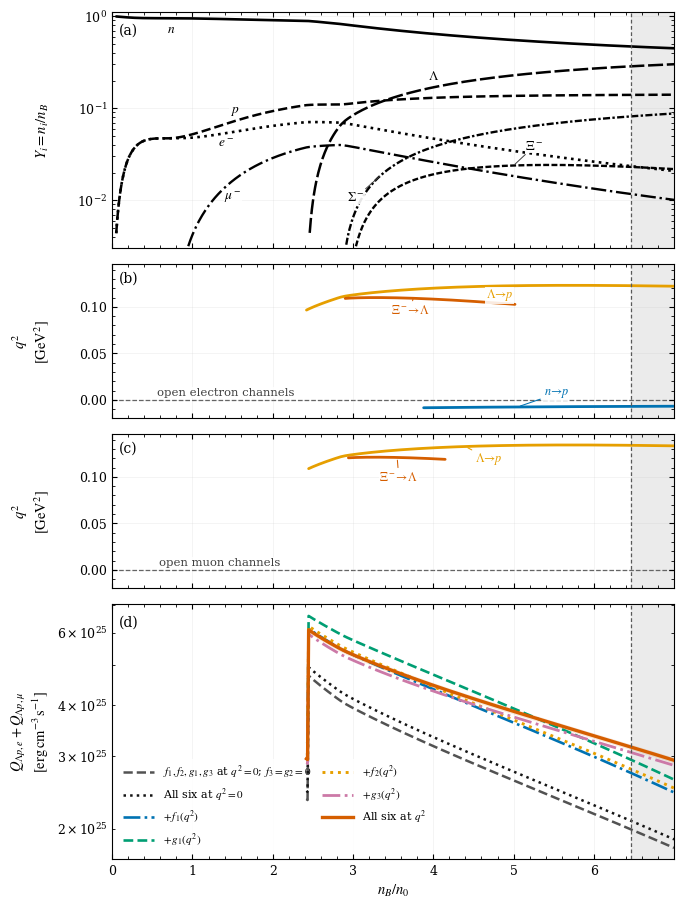

Creating FSU2R Figure 2...


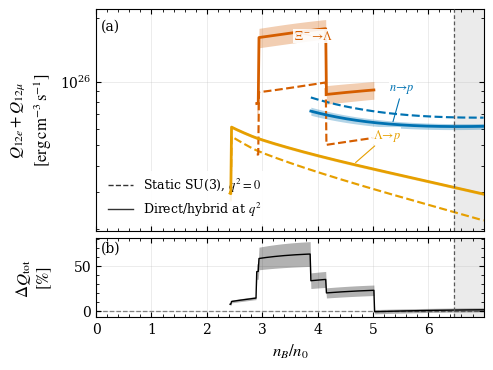

Creating FSU2R Figure 3...


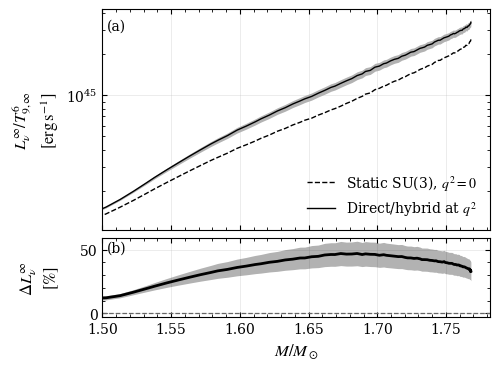

In [22]:
COMPOSITION_LABEL_POSITIONS = {
    "n":       {"x": 0.70, "dx":  2, "dy": -8},
    "p":       {"x": 1.45, "dx":  4, "dy":  8},
    "e":       {"x": 1.45, "dx": -2, "dy": -8},
    "mu":      {"x": 1.45, "dx":  3, "dy": -10},
    "Lambda":  {"x": 3.90, "dx":  6, "dy":  9},

    # strongly separated
    "Sigma-":  {"x": 3.35, "dx": -18, "dy": -16},
    "Xi-":     {"x": 5, "dx":  15, "dy":  14},

    "Sigma0":  {"x": 5.12, "dx": -2, "dy": -18},
    "Sigma+":  {"x": 6.45, "dx":  4, "dy":  7},
    "Xi0":     {"x": 6.52, "dx":  4, "dy": -9},
}
CHANNEL_LABEL_CONFIG = {
    "Xi_minus_to_Lambda": {
        # Anchor on the upper plateau, label shifted left/up
        "anchor_x": 3.60,
        "text_axes": (0.56, 0.88),
    },

    "Lambda_to_p": {
        # Move clearly below/right of Xi -> Lambda
        "anchor_x": 4.65,
        "text_axes": (0.75, 0.43),
    },

    "n_to_p": {
        "anchor_x": 5.35,
        "text_axes": (0.79, 0.64),
    },
}

# ============================================================
# FIX SHARED CHANNEL METADATA
#
# Figure 1 needs b1/b2 to reconstruct q_F^2.
# Figure 2 only needs label/color, but can safely use the
# same complete dictionary.
# ============================================================

from collections import OrderedDict

CHANNEL_STYLE = OrderedDict([
    (
        "n_to_p",
        {
            "b1": "n",
            "b2": "p",
            "label": r"$n\to p$",
            "color": "#0072B2",
        },
    ),
    (
        "Lambda_to_p",
        {
            "b1": "Lambda",
            "b2": "p",
            "label": r"$\Lambda\to p$",
            "color": "#E69F00",
        },
    ),
    (
        "Sigma_minus_to_n",
        {
            "b1": "Sigma-",
            "b2": "n",
            "label": r"$\Sigma^-\to n$",
            "color": "#009E73",
        },
    ),
    (
        "Xi_minus_to_Lambda",
        {
            "b1": "Xi-",
            "b2": "Lambda",
            "label": r"$\Xi^-\to\Lambda$",
            "color": "#D55E00",
        },
    ),
    (
        "Xi_minus_to_Xi0",
        {
            "b1": "Xi-",
            "b2": "Xi0",
            "label": r"$\Xi^-\to\Xi^0$",
            "color": "#CC79A7",
        },
    ),
    (
        "Xi0_to_Sigma_plus",
        {
            "b1": "Xi0",
            "b2": "Sigma+",
            "label": r"$\Xi^0\to\Sigma^+$",
            "color": "#56B4E9",
        },
    ),
])

# Quick sanity check
for name, cfg in CHANNEL_STYLE.items():
    assert "b1" in cfg
    assert "b2" in cfg
    assert "label" in cfg
    assert "color" in cfg

print("CHANNEL_STYLE repaired successfully.")
# ============================================================
# MAIN REFEREE COMPARISON
# ============================================================

EOS_RESULTS = OrderedDict()

for model_name in [
    "FSU2R",
]:

    EOS_RESULTS[model_name] = (
        run_complete_eos_analysis(
            model_name,
            eos_npts=520,
            tov_points=160,
            save_outputs=True,
            show_plots=True,
        )
    )